# **Time Series** <br> **Traffic Volume Prediction**
---
`Untuk latihan gemastik dan lainnya`

## **Dataset Description**
Dataset berisi data historis lalu lintas per jam dari suatu jalan. Data digunakan untuk **Time Series Regression** guna memprediksi volume lalu lintas (*traffic_volume*) berdasarkan fitur waktu dan kondisi cuaca.

---

## **Column Description**
| Kolom | Deskripsi |
|-------|-----------|
| **date_time** | Waktu pencatatan data (per jam) |
| **holiday** | Kategori hari libur nasional US (NaN jika bukan hari libur) |
| **temp** | Suhu rata-rata dalam satuan Kelvin |
| **rain_1h** | Curah hujan dalam mm yang terjadi dalam satu jam |
| **snow_1h** | Curah salju dalam mm yang terjadi dalam satu jam |
| **clouds_all** | Persentase tutupan awan (0-100%) |
| **weather_main** | Kategori cuaca utama (misal: *Clear, Clouds, Rain*) |
| **weather_description** | Deskripsi cuaca lebih detail (misal: *sky is clear, light rain*) |
| **traffic_volume** | Jumlah kendaraan yang melintas (Target Variable) |

---

## **Overview**
Fokus pada temporal feature dan membangun model **Time Series Forecasting** untuk memprediksi *traffic_volume*. Project ini membandingkan pendekatan Deep Learning (LSTM, CNN 1D), Machine Learning Ensemble (XGBoost, LightGBM, CatBoost) dengan base model prophet dan seasonal naive prediction.

---

## **1. Exploratory Data Analysis (EDA)**

1.  Melihat struktur Tabular, Instance, dan Informasi Statistik Dataset
2.  Pengecekan Missing Values dan Duplikasi data berdasarkan `date_time`
3.  Analisis struktur kolom `holiday` (Pengecekan *marking* libur pada jam 00:00 vs jam lainnya)
4.  Analisis *Missing Hour* / Celah Waktu (Gaps Analysis)
5.  Distribusi fitur numerik
6.  Analisis Time Series dan Dekomposisi Musiman

---

## **2. Preprocessing**

1. Handle duplicate
2. Drop useless feature
3. interpolasi missing value (34)
4. ganti NaN holiday ke None Object
5. ganti suhu ke celcius

---

## **3. Feature Engineering**

1.  Ekstraksi fitur waktu dari `date_time` (Jam, Hari, is_weekend)
2.  Handle Holiday to is_holiday - fill holiday ke keseluruhan hari
3.  Cyclical Encoding
4.  Traffic lag feature

---

## **4. Model Training**

1. **Baseline Model**
    - Seasonal Naive Prediction
    - Meta Prophet
2.  **Deep Learning (TensorFlow/Keras):**
    - LSTM (Long Short-Term Memory)
    - CNN 1D (Convolutional Neural Network 1D)
3.  **Ensemble Machine Learning (Optuna hyperparam tunning):**
    - XGBoost Regressor
    - LightGBM
    - CatBoost Regressor

---

## **5. Model Evaluation**

Evaluasi dilakukan menggunakan metrik regresi:
1.  Mean Absolute Error (MAE)
2.  Root Mean Squared Error (RMSE)
3.  R2 Score
4.  Mean Absolute Scaled Error (MASE) vs Naive
5.  Mean Absolute Scaled Error (MASE) vs Prophet

---

# Exploratory Data Analysis

In [1]:
import random

# Data Frame manip
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

# Preproses
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Tensor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, Flatten, MaxPooling1D, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

# Ensamble model
!pip install xgboost lightgbm catboost
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Optuna and hypertune
!pip install optuna xgboost lightgbm catboost
import optuna
from lightgbm import early_stopping, log_evaluation

# Base
from prophet import Prophet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 34.1 MB/s eta 0:00:00


In [2]:
import os
import gdown

def ensure_file(file_path, url):
    if not os.path.exists(file_path):
        print(f"{file_path} not found. Downloading...")
        gdown.download(url, file_path, quiet=False)
    else:
        print(f"{file_path} already exists.")

# Download File
ensure_file("test.csv", "https://drive.google.com/uc?id=1dOv5Vzu0HUDeJO7vC4iV0HubRpNtymjR")

test.csv not found. Downloading...


Downloading...
From: https://drive.google.com/uc?id=1dOv5Vzu0HUDeJO7vC4iV0HubRpNtymjR
To: /content/test.csv
100%|██████████| 3.24M/3.24M [00:00<00:00, 78.0MB/s]


In [3]:
def set_global_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_global_seed()

## Tabular Structure, Dataset Instance, and Information

In [4]:
# Load data set
df = pd.read_csv('/content/test.csv')

# Last 13149 Data
df = df.tail(13149)

# Data Instance
print("\nData instance:\n")
display(df.head())

# Columns Name
print("\nColumns Name :\n")
display(df.columns)

# General Info
print("\nGeneral Information on Dataset train\n")
display(df.info())

# Statistic Description
print("\nStatistic Description on Dataset train\n")
display(df.describe())

# Rows Total and Column
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Data instance:



,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
35055,NaN,295.16,0.0,0.0,40,Clouds,scattered clouds,2017-07-03 22:00:00,2106
35056,NaN,294.56,0.0,0.0,1,Clear,sky is clear,2017-07-03 23:00:00,1606
35057,Independence Day,293.41,0.0,0.0,1,Clear,sky is clear,2017-07-04 00:00:00,1225
35058,NaN,292.89,0.0,0.0,1,Clear,sky is clear,2017-07-04 01:00:00,746
35059,NaN,292.42,0.0,0.0,1,Clear,sky is clear,2017-07-04 02:00:00,592



Columns Name :



Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume'],
      dtype='object')


General Information on Dataset train

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13149 entries, 35055 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              17 non-null     object 
 1   temp                 13149 non-null  float64
 2   rain_1h              13149 non-null  float64
 3   snow_1h              13149 non-null  float64
 4   clouds_all           13149 non-null  int64  
 5   weather_main         13149 non-null  object 
 6   weather_description  13149 non-null  object 
 7   date_time            13149 non-null  object 
 8   traffic_volume       13149 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 924.7+ KB


None


Statistic Description on Dataset train



,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,13149.000000,13149.000000,13149.0,13149.000000,13149.000000
mean,283.143481,0.073611,0.0,47.011940,3302.231348
std,13.037397,0.488974,0.0,39.324966,1983.824052
min,246.150000,0.000000,0.0,0.000000,151.000000
25%,272.560000,0.000000,0.0,1.000000,1250.000000
50%,287.000000,0.000000,0.0,40.000000,3459.000000
75%,293.670000,0.000000,0.0,90.000000,4963.000000
max,310.070000,10.600000,0.0,92.000000,7213.000000


Rows: 13149, Columns: 9


## Missing Values & Duplicates based on date_time

In [5]:
# obj -> datetime
df['date_time'] = pd.to_datetime(df['date_time'])

# Display count of missing values per column
display(df.isnull().sum())

# Check for duplicates based on the 'date_time'
display(df[df["date_time"].duplicated(keep=False)])

,0
holiday,13132
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
35082,NaN,296.15,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2017-07-05 01:00:00,698
35083,NaN,296.15,0.0,0.0,90,Mist,mist,2017-07-05 01:00:00,698
35084,NaN,296.15,0.0,0.0,90,Rain,heavy intensity rain,2017-07-05 01:00:00,698
35085,NaN,295.97,0.0,0.0,75,Thunderstorm,proximity thunderstorm,2017-07-05 02:00:00,428
35086,NaN,295.97,0.0,0.0,75,Rain,light rain,2017-07-05 02:00:00,428
...,...,...,...,...,...,...,...,...,...
48173,NaN,280.68,0.0,0.0,90,Clouds,overcast clouds,2018-09-29 19:00:00,3818
48192,NaN,283.48,0.0,0.0,90,Rain,light rain,2018-09-30 14:00:00,4380
48193,NaN,283.48,0.0,0.0,90,Drizzle,light intensity drizzle,2018-09-30 14:00:00,4380
48194,NaN,283.84,0.0,0.0,75,Rain,proximity shower rain,2018-09-30 15:00:00,4302


Terdapat data duplikat yang menunjukan waktu, dan data statistik yang sama namun memiliki keterangan cuaca utama dan deskripsi cuaca yang berbeda. Hal ini besa menyebabkan perhitungan numerik tidak menunjukan yang semestinya dan mengganggu persebaran.
Untuk saat ini akan dilakukan pemisahan ke 2 data yaitu :
1. no dup : drop untuk data duplikat untuk melakukan pendekatan EDA numeric coloumn
2. keep : tetap menyimpan untuk pembacaan weather_main dan weather_desc

In [6]:
df_nodup = df.drop_duplicates(subset='date_time', keep='first')
df_keep = df.copy()

### Cek struktur holiday

In [7]:
df[df['holiday'].notna()]

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
35057,Independence Day,293.410,0.00,0.0,1,Clear,sky is clear,2017-07-04,1225
36551,State Fair,289.690,0.00,0.0,90,Rain,light rain,2017-08-24,657
36882,Labor Day,295.540,0.00,0.0,1,Clear,sky is clear,2017-09-04,1026
37882,Columbus Day,284.620,0.00,0.0,1,Clear,sky is clear,2017-10-09,549
38803,Veterans Day,261.680,0.00,0.0,1,Clear,sky is clear,2017-11-10,812
39180,Thanksgiving Day,271.940,0.00,0.0,1,Clear,sky is clear,2017-11-23,1324
40057,Christmas Day,257.950,0.00,0.0,1,Clear,sky is clear,2017-12-25,1092
40255,New Years Day,249.360,0.00,0.0,1,Clear,sky is clear,2018-01-01,1478
40655,Martin Luther King Jr Day,262.540,0.00,0.0,90,Snow,light snow,2018-01-15,600
40656,Martin Luther King Jr Day,262.540,0.00,0.0,90,Mist,mist,2018-01-15,600


In [8]:
df_holiday_keepdup = df_keep[df_keep['holiday'].notna()]
df_holiday = df_nodup[df_nodup['holiday'].notna()]

# Check all the unique value
display(df_holiday['holiday'].unique())
print(f"\nTotal banyak baris (keepdup) : {len(df_holiday_keepdup)}")
print(f"\nTotal banyak baris (nodup) : {len(df_holiday)}")
print(f"\nTotal banyak uniq-value : {len(df_holiday['holiday'].unique())}")



array(['Independence Day', 'State Fair', 'Labor Day', 'Columbus Day',
       'Veterans Day', 'Thanksgiving Day', 'Christmas Day',
       'New Years Day', 'Martin Luther King Jr Day',
       'Washingtons Birthday', 'Memorial Day'], dtype=object)


Total banyak baris (keepdup) : 17

Total banyak baris (nodup) : 14

Total banyak uniq-value : 11


Pada data diatas terdapat 11 jenis uniq Holiday yang terjadi pada 13149 dataset dan 17 instance pada dataset dimana tiga diantaranya merupakan duplicate.<br>
Namun Mengapa datetime ditulis dalam format YYYY-MM-DD dan tidak YYYY-MM-DD HH:MM:SS?
<br>
Untuk melihat hal itu dilakukan pengecekan data sebelum dan sesudah marking holiday

In [9]:
unique_holiday_dates = df_nodup[df_nodup['holiday'].notna()]['date_time'].dt.normalize().unique()

print("Checking data around holidays:")
for holiday_date in unique_holiday_dates:
    print(f"\n{holiday_date.strftime('%Y-%m-%d')}:")

    # Get 1 hour before, during, and 1 hour after holiday
    before = df_nodup[df_nodup['date_time'] == holiday_date - pd.Timedelta(hours=1)]
    during = df_nodup[df_nodup['date_time'] == holiday_date]
    after = df_nodup[df_nodup['date_time'] == holiday_date + pd.Timedelta(hours=1)]

    combined = pd.concat([before, during, after])
    display(combined[['date_time', 'holiday']])

Checking data around holidays:

2017-07-04:


,date_time,holiday
35056,2017-07-03 23:00:00,NaN
35057,2017-07-04 00:00:00,Independence Day
35058,2017-07-04 01:00:00,NaN



2017-08-24:


,date_time,holiday
36550,2017-08-23 23:00:00,NaN
36551,2017-08-24 00:00:00,State Fair
36552,2017-08-24 01:00:00,NaN



2017-09-04:


...

,date_time,holiday
45546,2018-07-03 23:00:00,NaN
45547,2018-07-04 00:00:00,Independence Day
45548,2018-07-04 01:00:00,NaN



2018-08-23:


,date_time,holiday
46935,2018-08-22 23:00:00,NaN
46936,2018-08-23 00:00:00,State Fair
46937,2018-08-23 01:00:00,NaN



2018-09-03:


,date_time,holiday
47328,2018-09-02 23:00:00,NaN
47330,2018-09-03 00:00:00,Labor Day
47332,2018-09-03 01:00:00,NaN


1. Holiday dimark pada awal hari pada pukul 00:00 (menjelaskan mengapa ke round ke YYYY-MM-DD)

2. Walaupun pada hari yang sama, jam selanjutnya dari pukul 01:00-23:00 tidak dimark sebagai holiday

### Missing hour

In [10]:
df_mh = df.copy()

# Drop duplicate rows and sort
df_mh = df_mh.drop_duplicates(subset='date_time', keep='first')
df_mh = df_mh.sort_values('date_time').reset_index(drop=True)
df_mh.index = df_mh['date_time']

# Calculate time differences between consecutive timestamps
time_diffs = df_mh.index.to_series().diff()

# Set expected frequency (1 hour)
expected_freq = pd.Timedelta(hours=1)

# Find where gaps occur
gaps_mask = time_diffs > expected_freq
gap_data = []
for i in range(len(df_mh)):
    if gaps_mask.iloc[i]:
        gap_data.append({
            'before_gap': df_mh.index[i-1],
            'after_gap': df_mh.index[i],
            'gap_hours': int((time_diffs.iloc[i] / expected_freq) - 1)
        })
if gap_data:
    gap_table = pd.DataFrame(gap_data)
    gap_table.index = range(1, len(gap_table) + 1)
    gap_table.index.name = 'gap_number'

    print(f"FOUND {len(gap_table)} GAP(S) - Total missing: {gap_table['gap_hours'].sum()} hours")
    print("=" * 70)
    display(gap_table)

FOUND 23 GAP(S) - Total missing: 34 hours


,before_gap,after_gap,gap_hours
gap_number,,,
1,2017-07-10 09:00:00,2017-07-10 11:00:00,1
2,2017-07-10 14:00:00,2017-07-10 16:00:00,1
3,2017-08-16 03:00:00,2017-08-16 05:00:00,1
4,2017-09-21 09:00:00,2017-09-21 13:00:00,3
5,2017-09-27 22:00:00,2017-09-28 00:00:00,1
6,2017-11-08 01:00:00,2017-11-08 03:00:00,1
7,2017-11-09 01:00:00,2017-11-09 03:00:00,1
8,2017-11-11 01:00:00,2017-11-11 03:00:00,1
9,2017-11-15 01:00:00,2017-11-15 03:00:00,1


## Numerical col Distribution

1. temp
2. rain_1h
3. snow_1h
4. clouds_all
5. traffic_volume


### Histogram

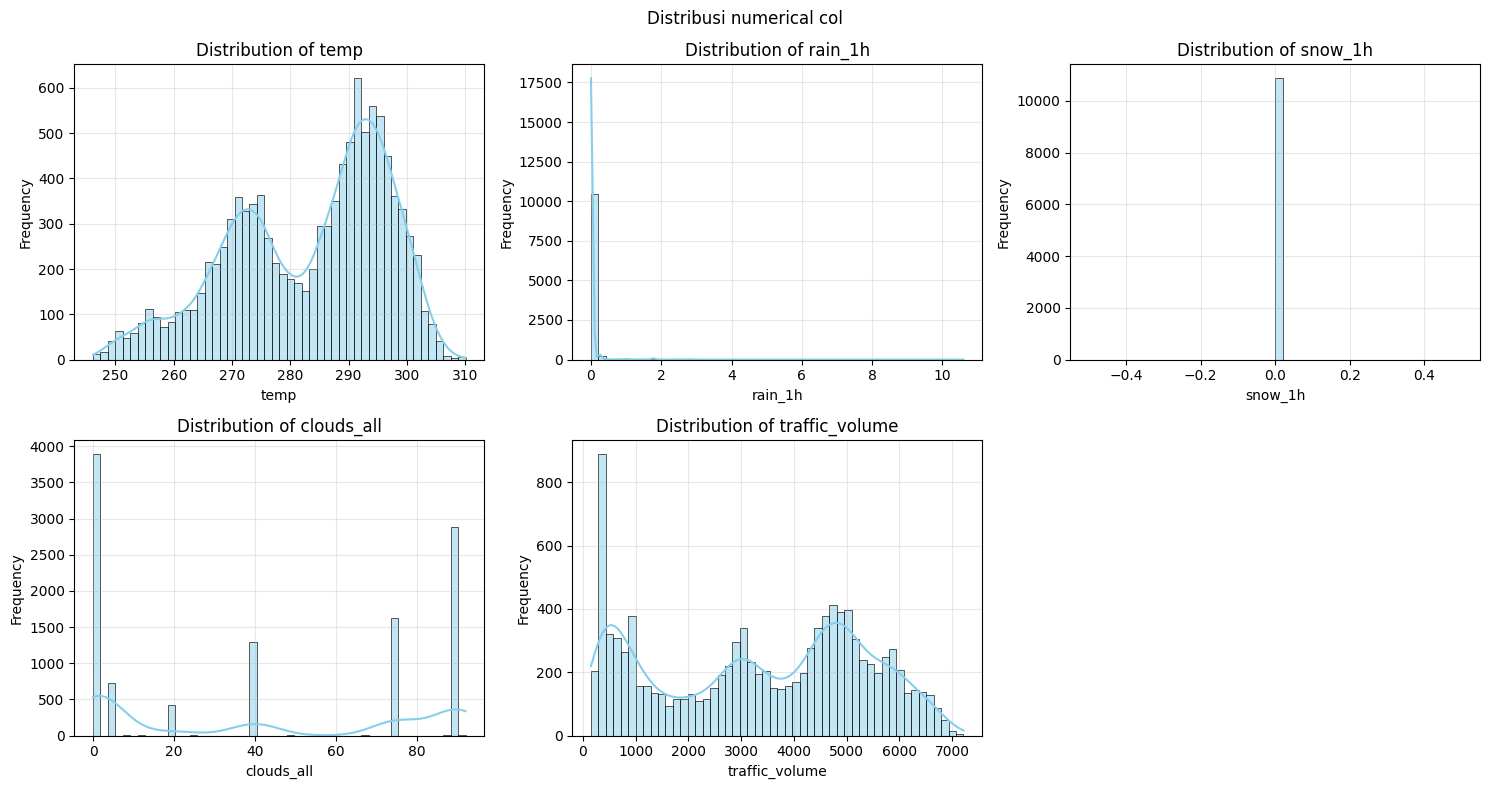

In [11]:
# menggunakan nodup data
num_cols = df_nodup.select_dtypes(include='number').columns

# Plot histogram for each numerical column
plt.figure(figsize=(15, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)

    sns.histplot(
        df_nodup[col],
        bins=50, kde=True,
        color='skyblue',
        edgecolor='black'
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)

plt.suptitle('Distribusi numerical col')
plt.tight_layout()
plt.show()

In [12]:
# Snow 1H hanya memiliki 1 value yaitu 0.0
display(df['snow_1h'].value_counts())

print("\nBaris pertama:")
display(df[["date_time", "snow_1h", "traffic_volume"]].iloc[[0]])

print("\nBaris terakhir:")
display(df[["date_time", "snow_1h", "traffic_volume"]].iloc[[-1]])

print(f"\n Pada {df["date_time"].iloc[0]} hingga {df["date_time"].iloc[-1]} salju tidak turun sama sekali")

,count
snow_1h,
0.0,13149



Baris pertama:


,date_time,snow_1h,traffic_volume
35055,2017-07-03 22:00:00,0.0,2106



Baris terakhir:


,date_time,snow_1h,traffic_volume
48203,2018-09-30 23:00:00,0.0,954



 Pada 2017-07-03 22:00:00 hingga 2018-09-30 23:00:00 salju tidak turun sama sekali


### Boxplot (Outlier)

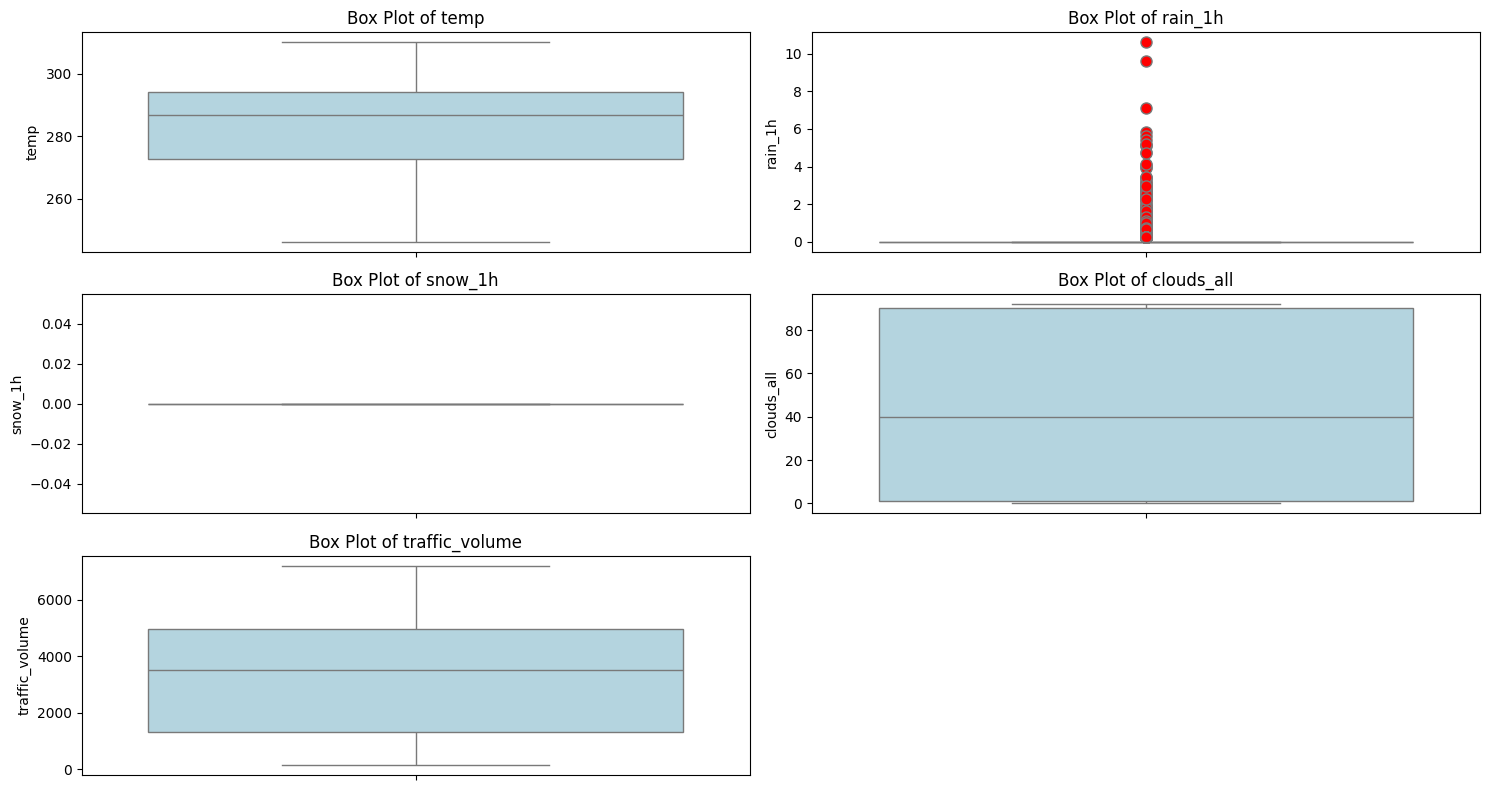

In [13]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i + 1)
    flierprops = dict(marker='o', markerfacecolor='red', markersize=8, linestyle='none')
    sns.boxplot(y=df_nodup[col], color='lightblue', flierprops=flierprops)
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### Numerical Outlier

In [14]:
# Outlier Counter

outlier_summary = []
for col in num_cols:
    # Calculate Q1, Q3, and IQR
    Q1 = df_nodup[col].quantile(0.25)
    Q3 = df_nodup[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers
    outliers = df_nodup[(df_nodup[col] < lower_bound) | (df_nodup[col] > upper_bound)]
    outlier_count = len(outliers)

    # Store summary
    outlier_summary.append({
        'column': col,
        'total_outliers': outlier_count,
        'percentage': f"{(outlier_count/len(df_nodup)*100):.2f}%",
        'lower_bound': f"{lower_bound:.2f}",
        'upper_bound': f"{upper_bound:.2f}"
    })

    # Display details for each column
    if outlier_count > 0:
        print(f"\n{'='*70}\nColumn: {col}\n{'='*70}")
        print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
        print(f"Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")
        print(f"Total Outliers: {outlier_count} ({(outlier_count/len(df_nodup)*100):.2f}%)")
        print(f"\nOutlier values and their timestamps:")
        display(outliers[['date_time', col]].sort_values(col, ascending=False))
    else:
        print(f"\n {col}: No outliers detected")

# Summary table
print("\n" + "=" * 70)
print("OUTLIER SUMMARY TABLE")
print("=" * 70)
summary_df = pd.DataFrame(outlier_summary)
display(summary_df)


 temp: No outliers detected

Column: rain_1h
Q1: 0.00 | Q3: 0.00 | IQR: 0.00
Lower Bound: 0.00 | Upper Bound: 0.00
Total Outliers: 401 (3.69%)

Outlier values and their timestamps:


,date_time,rain_1h
47929,2018-09-20 19:00:00,10.60
47924,2018-09-20 18:00:00,9.62
47933,2018-09-20 20:00:00,7.11
46994,2018-08-24 12:00:00,5.84
47009,2018-08-24 17:00:00,5.62
...,...,...
48088,2018-09-26 08:00:00,0.25
48109,2018-09-27 05:00:00,0.25
48116,2018-09-27 11:00:00,0.25
48153,2018-09-29 00:00:00,0.25



 snow_1h: No outliers detected

 clouds_all: No outliers detected

 traffic_volume: No outliers detected

OUTLIER SUMMARY TABLE


,column,total_outliers,percentage,lower_bound,upper_bound
0,temp,0,0.00%,240.26,326.37
1,rain_1h,401,3.69%,0.00,0.00
2,snow_1h,0,0.00%,0.00,0.00
3,clouds_all,0,0.00%,-132.50,223.50
4,traffic_volume,0,0.00%,-4163.75,10466.25


## Numerical Feature Correlation

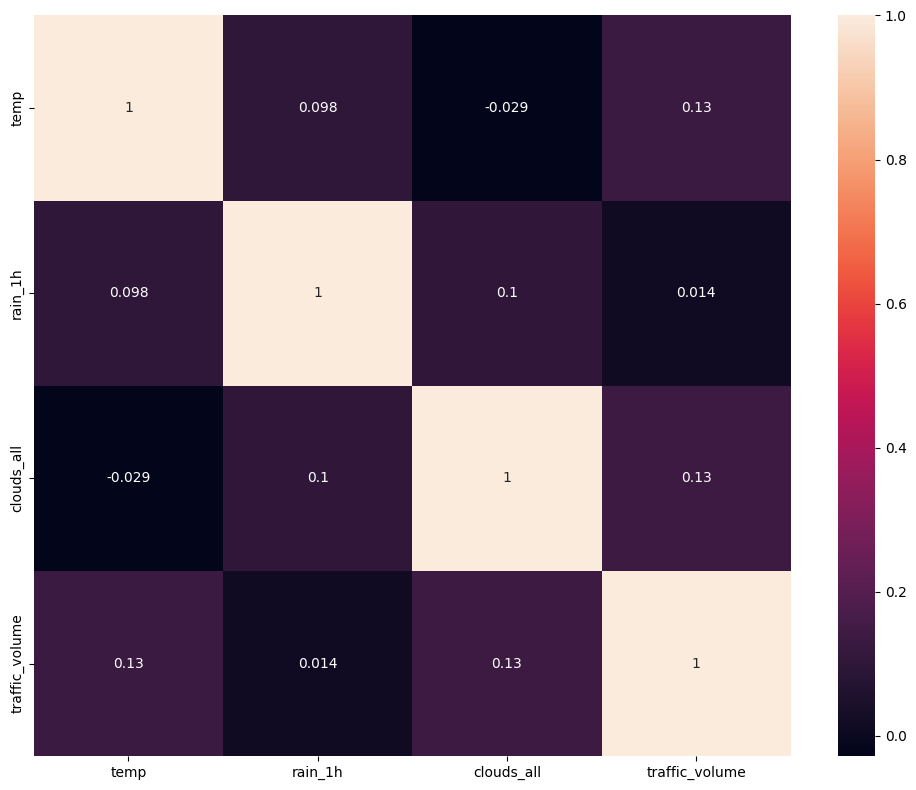

In [15]:
# exclude snow_1h
corr_num_col = ['temp', 'rain_1h', 'clouds_all', 'traffic_volume']

# Calculate correlation matrix
correlation_matrix = df_keep[corr_num_col].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True)
plt.tight_layout()
plt.show()

## Weather

In [16]:
# Numerical

print("Value counts for 'weather_main' column:")
display(df_keep['weather_main'].value_counts())

print(f"\nUnique values for 'weather_main' column (count : {len(df_keep['weather_main'].unique())}):")
display(df_keep['weather_main'].unique())

print("Value counts for 'weather_description' column:")
display(df_keep['weather_description'].value_counts())

print(f"\nUnique values for 'weather_description' column (count : {len(df_keep['weather_description'].unique())}):")
display(df_keep['weather_description'].unique())

Value counts for 'weather_main' column:


,count
weather_main,
Clear,3734
Clouds,3553
Mist,1800
Rain,1523
Snow,806
Drizzle,530
Haze,448
Thunderstorm,419
Fog,333



Unique values for 'weather_main' column (count : 10):


array(['Clouds', 'Clear', 'Thunderstorm', 'Mist', 'Rain', 'Drizzle',
       'Haze', 'Fog', 'Smoke', 'Snow'], dtype=object)

Value counts for 'weather_description' column:


,count
weather_description,
sky is clear,3717
mist,1800
broken clouds,1154
overcast clouds,1027
scattered clouds,1003
light rain,820
light snow,666
moderate rain,490
haze,448



Unique values for 'weather_description' column (count : 32):


array(['scattered clouds', 'sky is clear', 'few clouds', 'broken clouds',
       'proximity thunderstorm', 'mist', 'heavy intensity rain',
       'light rain', 'moderate rain', 'light intensity drizzle',
       'thunderstorm', 'Sky is Clear', 'proximity shower rain', 'haze',
       'fog', 'overcast clouds', 'thunderstorm with rain',
       'thunderstorm with heavy rain', 'drizzle',
       'light intensity shower rain', 'proximity thunderstorm with rain',
       'heavy intensity drizzle', 'thunderstorm with light rain',
       'thunderstorm with light drizzle', 'smoke',
       'proximity thunderstorm with drizzle', 'light snow', 'snow',
       'heavy snow', 'light shower snow', 'shower drizzle', 'sleet'],
      dtype=object)

Barchart frekuensi tiap Weather Main


/tmp/ipython-input-2976151697.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


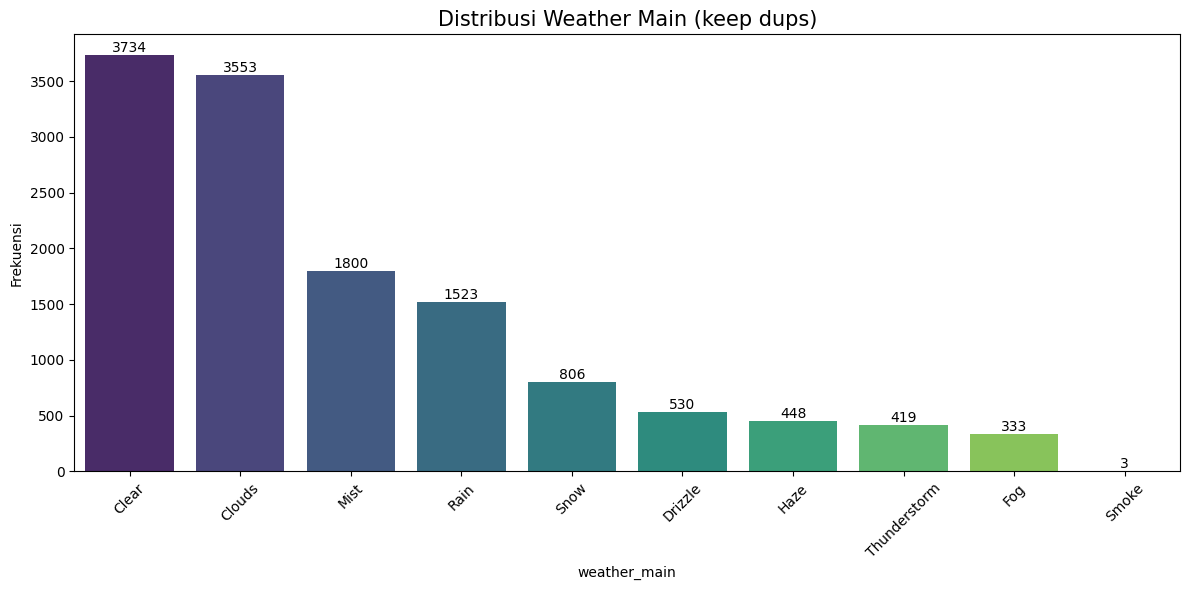

In [17]:
# Visual

print("Barchart frekuensi tiap Weather Main")

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    x='weather_main',
    data=df_keep,
    order=df_keep['weather_main'].value_counts().index,
    palette='viridis'
)
plt.title('Distribusi Weather Main (keep dups)', fontsize=15)
plt.xlabel('weather_main')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45)
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

Walaupun snow_1h selalu 0 sepanjang dataset, namun ada kondisi dimana cuaca terdeteksi sebagai cuaca snow

In [18]:
df_snow_sample = df_keep.copy()
df_snow_sample['date_time'] = pd.to_datetime(df_snow_sample['date_time'])
df_snow_sample[
    (df_snow_sample['date_time'] >= "2017-12-11 00:00") &
    (df_snow_sample['date_time'] <= "2017-12-11 23:00") &
    (df_snow_sample['weather_main'] == 'Snow')
]


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
39664,NaN,269.07,0.0,0.0,40,Snow,light snow,2017-12-11 00:00:00,542
39665,NaN,269.72,0.0,0.0,90,Snow,snow,2017-12-11 01:00:00,281
39668,NaN,269.86,0.0,0.0,90,Snow,light snow,2017-12-11 02:00:00,279
39671,NaN,270.01,0.0,0.0,90,Snow,light snow,2017-12-11 03:00:00,353
39673,NaN,270.68,0.0,0.0,90,Snow,light snow,2017-12-11 04:00:00,901
39675,NaN,270.81,0.0,0.0,90,Snow,light snow,2017-12-11 05:00:00,2907
39676,NaN,271.15,0.0,0.0,90,Snow,light snow,2017-12-11 06:00:00,5061
39677,NaN,271.55,0.0,0.0,90,Snow,light snow,2017-12-11 07:00:00,4050
39680,NaN,271.75,0.0,0.0,90,Snow,snow,2017-12-11 08:00:00,4349
39683,NaN,272.44,0.0,0.0,90,Snow,light snow,2017-12-11 09:00:00,4734


Barchart frekuensi tiap Weather Desc


/tmp/ipython-input-2407213136.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


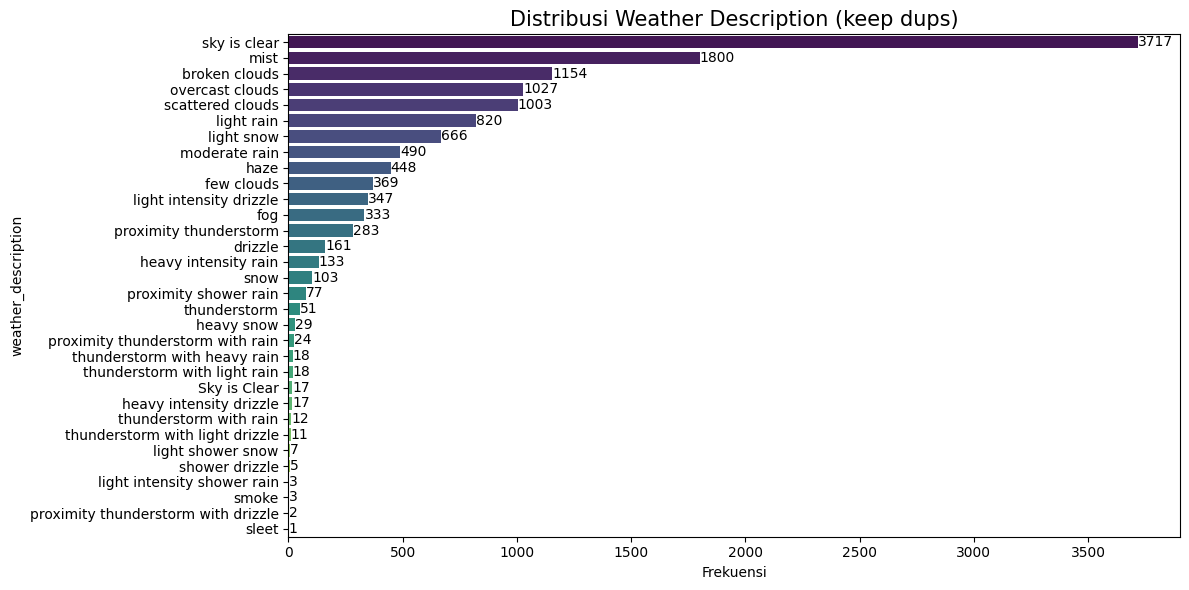

In [19]:
print("Barchart frekuensi tiap Weather Desc")

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    y='weather_description',
    data=df_keep,
    order=df_keep['weather_description'].value_counts().index,
    palette='viridis'
)

plt.title('Distribusi Weather Description (keep dups)', fontsize=15)
plt.xlabel('Frekuensi')
plt.ylabel('weather_description')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Boxplot and Avarage Traffic/Weather

/tmp/ipython-input-309422050.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipython-input-309422050.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


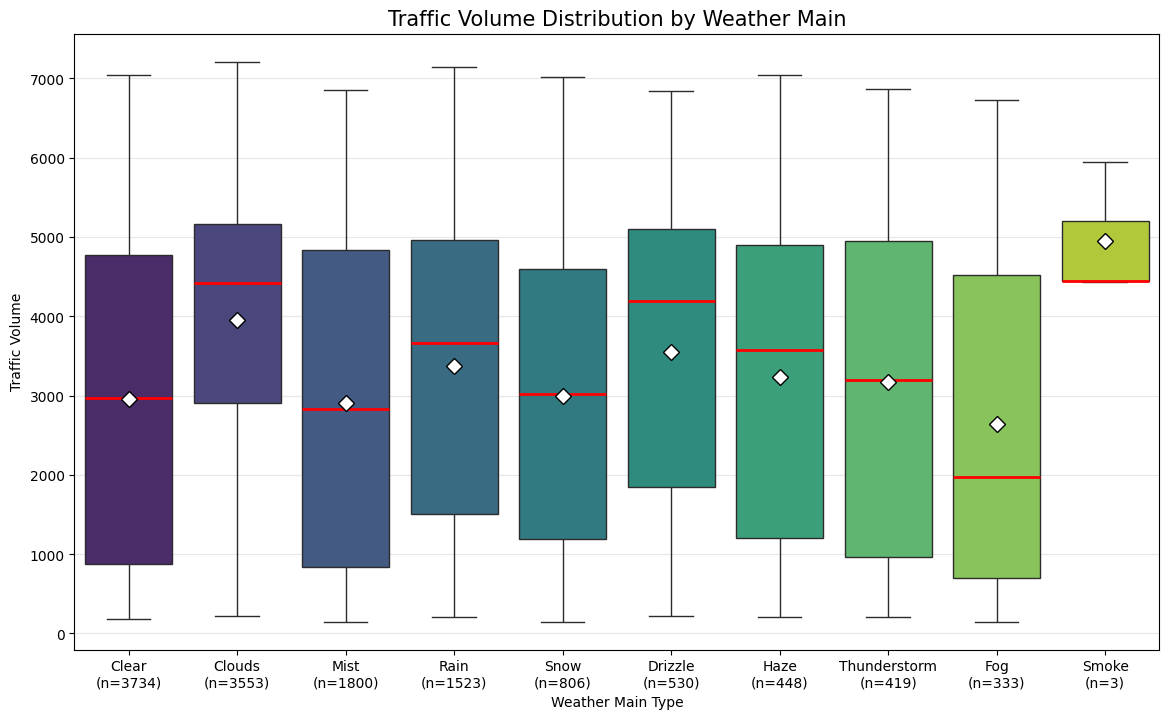

In [20]:
plt.figure(figsize=(14, 8))

# Create the boxplot
ax = sns.boxplot(
    x='weather_main',
    y='traffic_volume',
    data=df_keep,
    palette='viridis',
    showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize": "8"},
    medianprops={"color": "red","linewidth": 2},
    order=df_keep['weather_main'].value_counts().index # Sort by frequency
)

# Calculate counts for labels
counts = df_keep['weather_main'].value_counts()
labels = [f'{l}\n(n={counts[l]})' for l in counts.index]

# Update labels
ax.set_xticklabels(labels)

plt.title('Traffic Volume Distribution by Weather Main', fontsize=15)
plt.xlabel('Weather Main Type')
plt.ylabel('Traffic Volume')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

/tmp/ipython-input-1525199677.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipython-input-1525199677.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


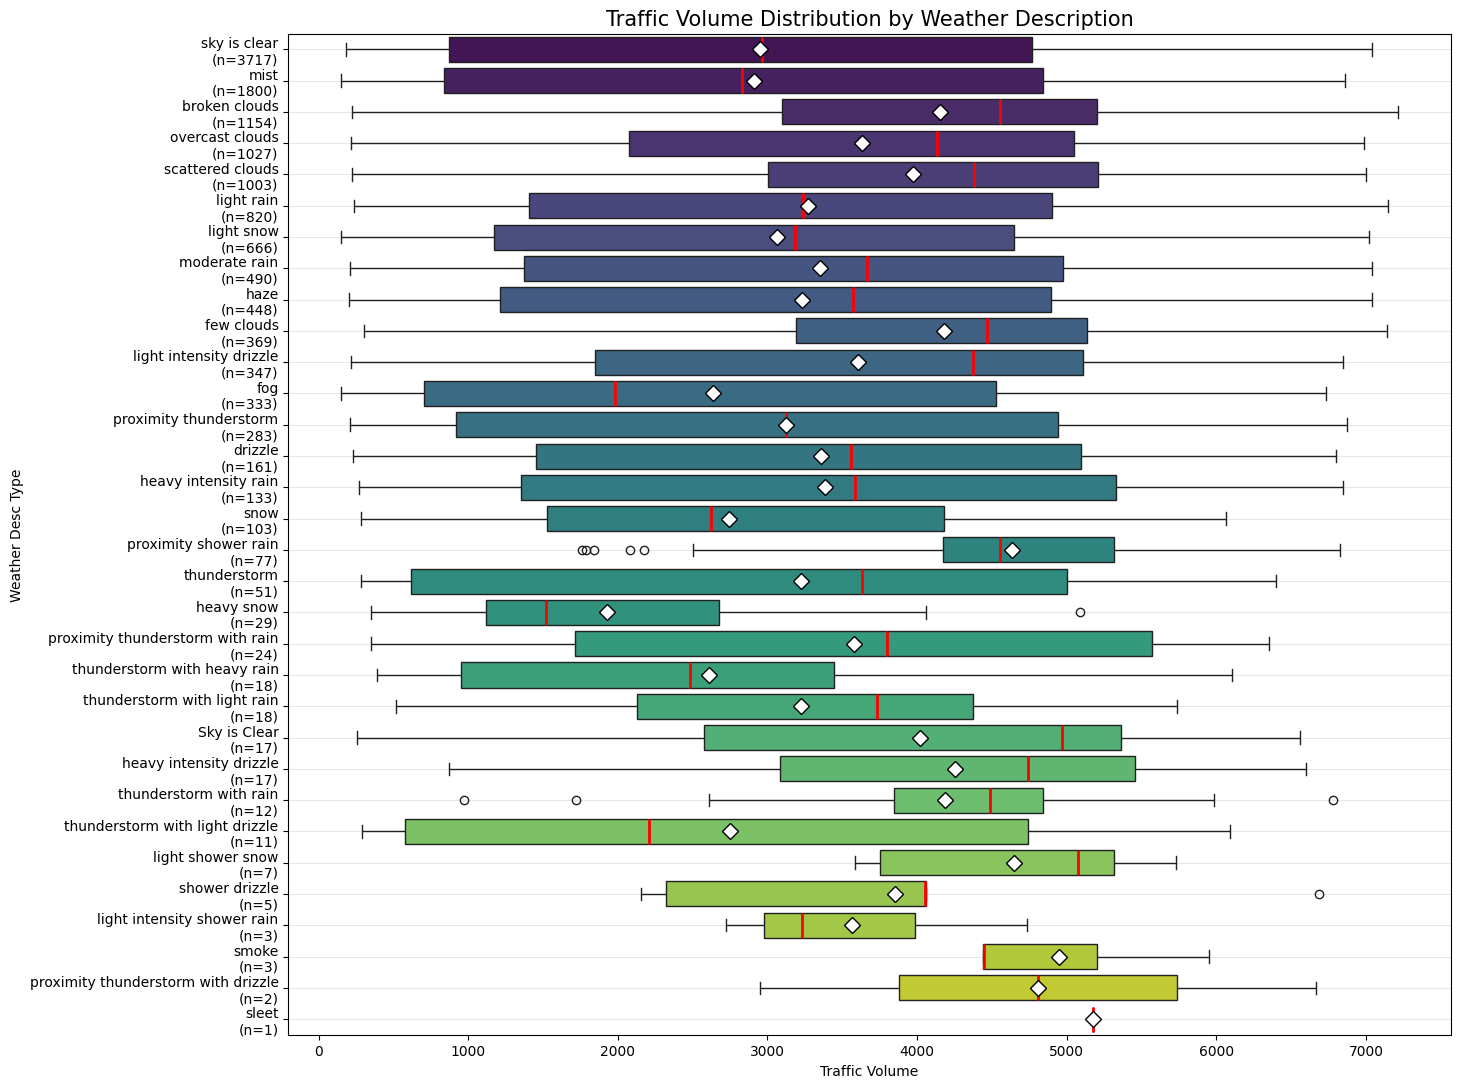

In [21]:
plt.figure(figsize=(15, 13))

# Create the boxplot
ax = sns.boxplot(
    y='weather_description',
    x='traffic_volume',
    data=df_keep,
    palette='viridis',
    order=df_keep['weather_description'].value_counts().index, # Sort by frequency
    showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize": "8"},
    medianprops={"color": "red","linewidth": 2}
)

# Calculate counts for labels
counts = df_keep['weather_description'].value_counts()
labels = [f'{l}\n(n={counts[l]})' for l in counts.index]

# Update labels
ax.set_yticklabels(labels)

plt.title('Traffic Volume Distribution by Weather Description', fontsize=15)
plt.ylabel('Weather Desc Type')
plt.xlabel('Traffic Volume')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

## Time Series

Traffic Volume Time Series Analysis (no dups)



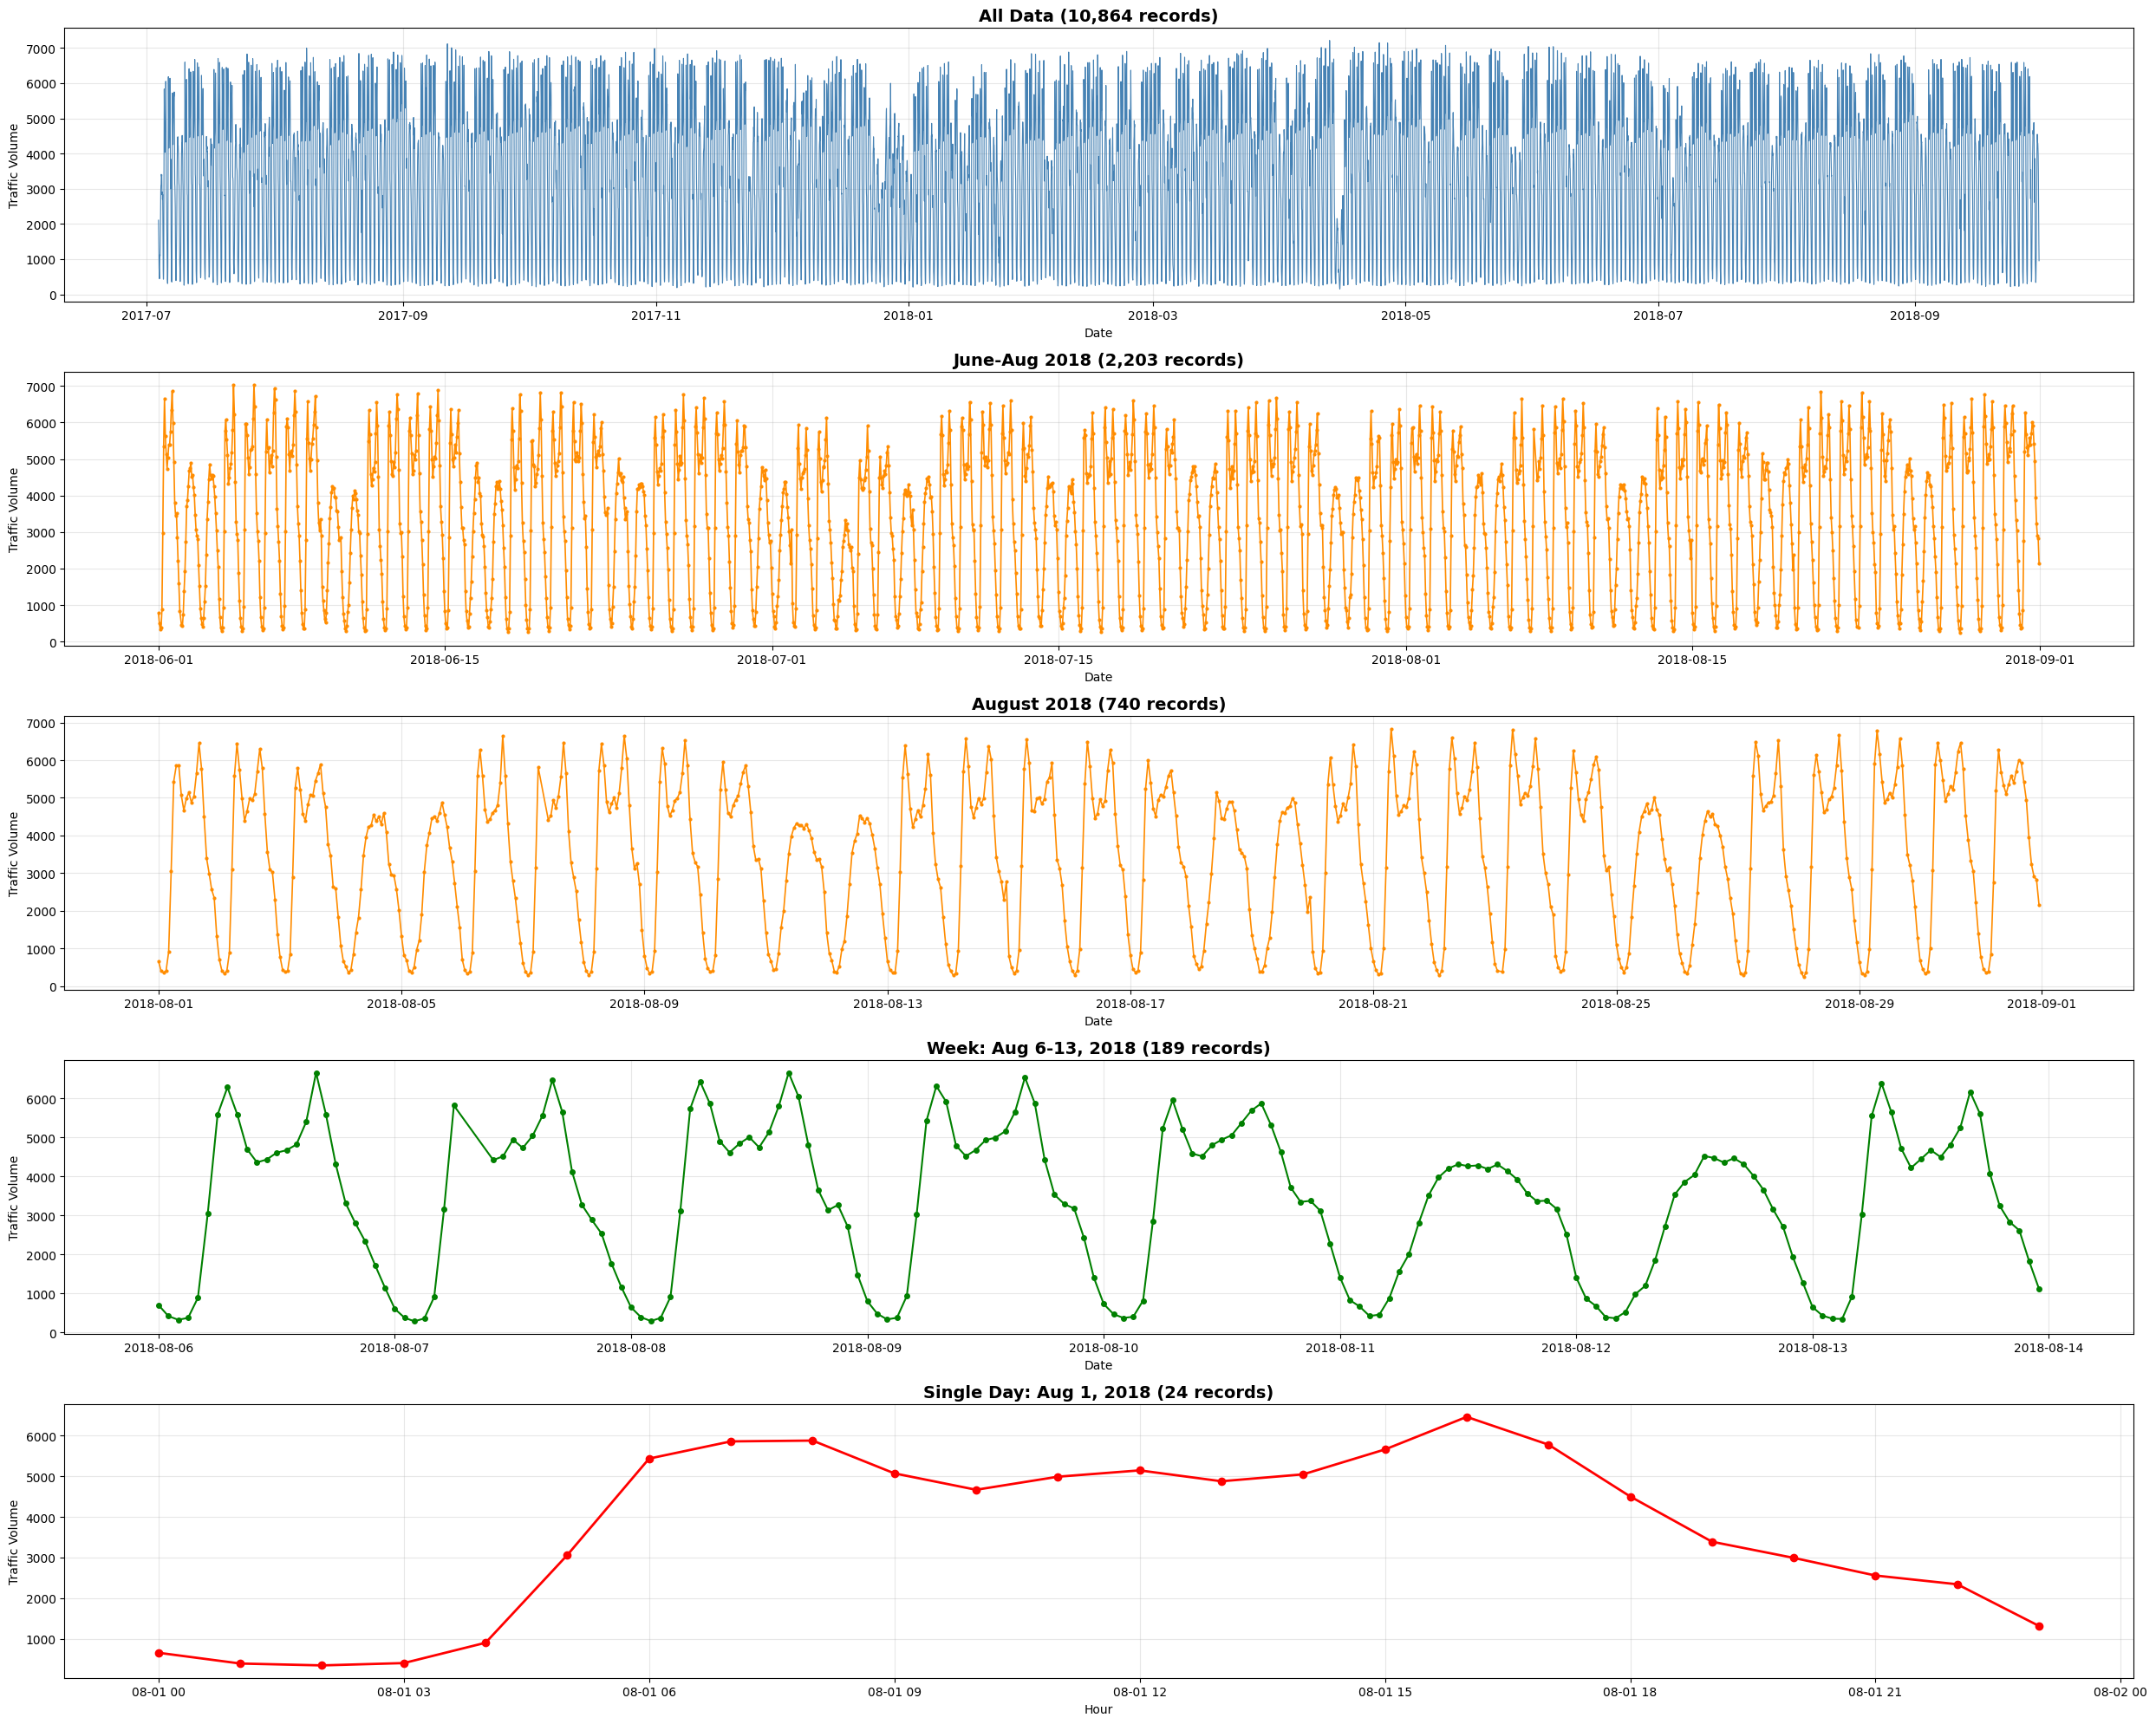

In [22]:
print("Traffic Volume Time Series Analysis (no dups)\n")

df_ts = df_nodup.copy()
df_ts['date_time'] = pd.to_datetime(df_ts['date_time'])
df_ts = df_ts.set_index('date_time').sort_index()

# Create subplots
fig, axes = plt.subplots(5, 1, figsize=(25, 20))

# 1. All data
axes[0].plot(df_ts["traffic_volume"], linewidth=0.8, color='steelblue')
axes[0].set_title(f'All Data ({len(df_ts):,} records)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Traffic Volume')
axes[0].grid(True, alpha=0.3)

# 2. Three month (June, July, Aug, 2018)
month_data = df_ts.loc['2018-06':'2018-08']
axes[1].plot(month_data["traffic_volume"], linewidth=1.2, color='darkorange', marker='o', markersize=2)
axes[1].set_title(f'June-Aug 2018 ({len(month_data):,} records)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Traffic Volume')
axes[1].grid(True, alpha=0.3)

# 3. One month (August 2018)
month_data = df_ts.loc['2018-08']
axes[2].plot(month_data["traffic_volume"], linewidth=1.2, color='darkorange', marker='o', markersize=2)
axes[2].set_title(f'August 2018 ({len(month_data):,} records)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Traffic Volume')
axes[2].grid(True, alpha=0.3)

# 4. One week (Aug 6-13, 2018)
week_data = df_ts.loc['2018-08-06':'2018-08-13']
axes[3].plot(week_data["traffic_volume"], linewidth=1.5, color='green', marker='o', markersize=4)
axes[3].set_title(f'Week: Aug 6-13, 2018 ({len(week_data):,} records)', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Date')
axes[3].set_ylabel('Traffic Volume')
axes[3].grid(True, alpha=0.3)

# 5. One day (Aug 1, 2018)
day_data = df_ts.loc['2018-08-01']
axes[4].plot(day_data["traffic_volume"], linewidth=2, color='red', marker='o', markersize=6)
axes[4].set_title(f'Single Day: Aug 1, 2018 ({len(day_data):,} records)', fontsize=14, fontweight='bold')
axes[4].set_xlabel('Hour')
axes[4].set_ylabel('Traffic Volume')
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Day on the week of the above chart
unique_dates = week_data.index.normalize().unique()
for date in unique_dates:
    print(date.strftime('%A, %B %d, %Y'))

Monday, August 06, 2018
Tuesday, August 07, 2018
Wednesday, August 08, 2018
Thursday, August 09, 2018
Friday, August 10, 2018
Saturday, August 11, 2018
Sunday, August 12, 2018
Monday, August 13, 2018


Seasonal Decompose

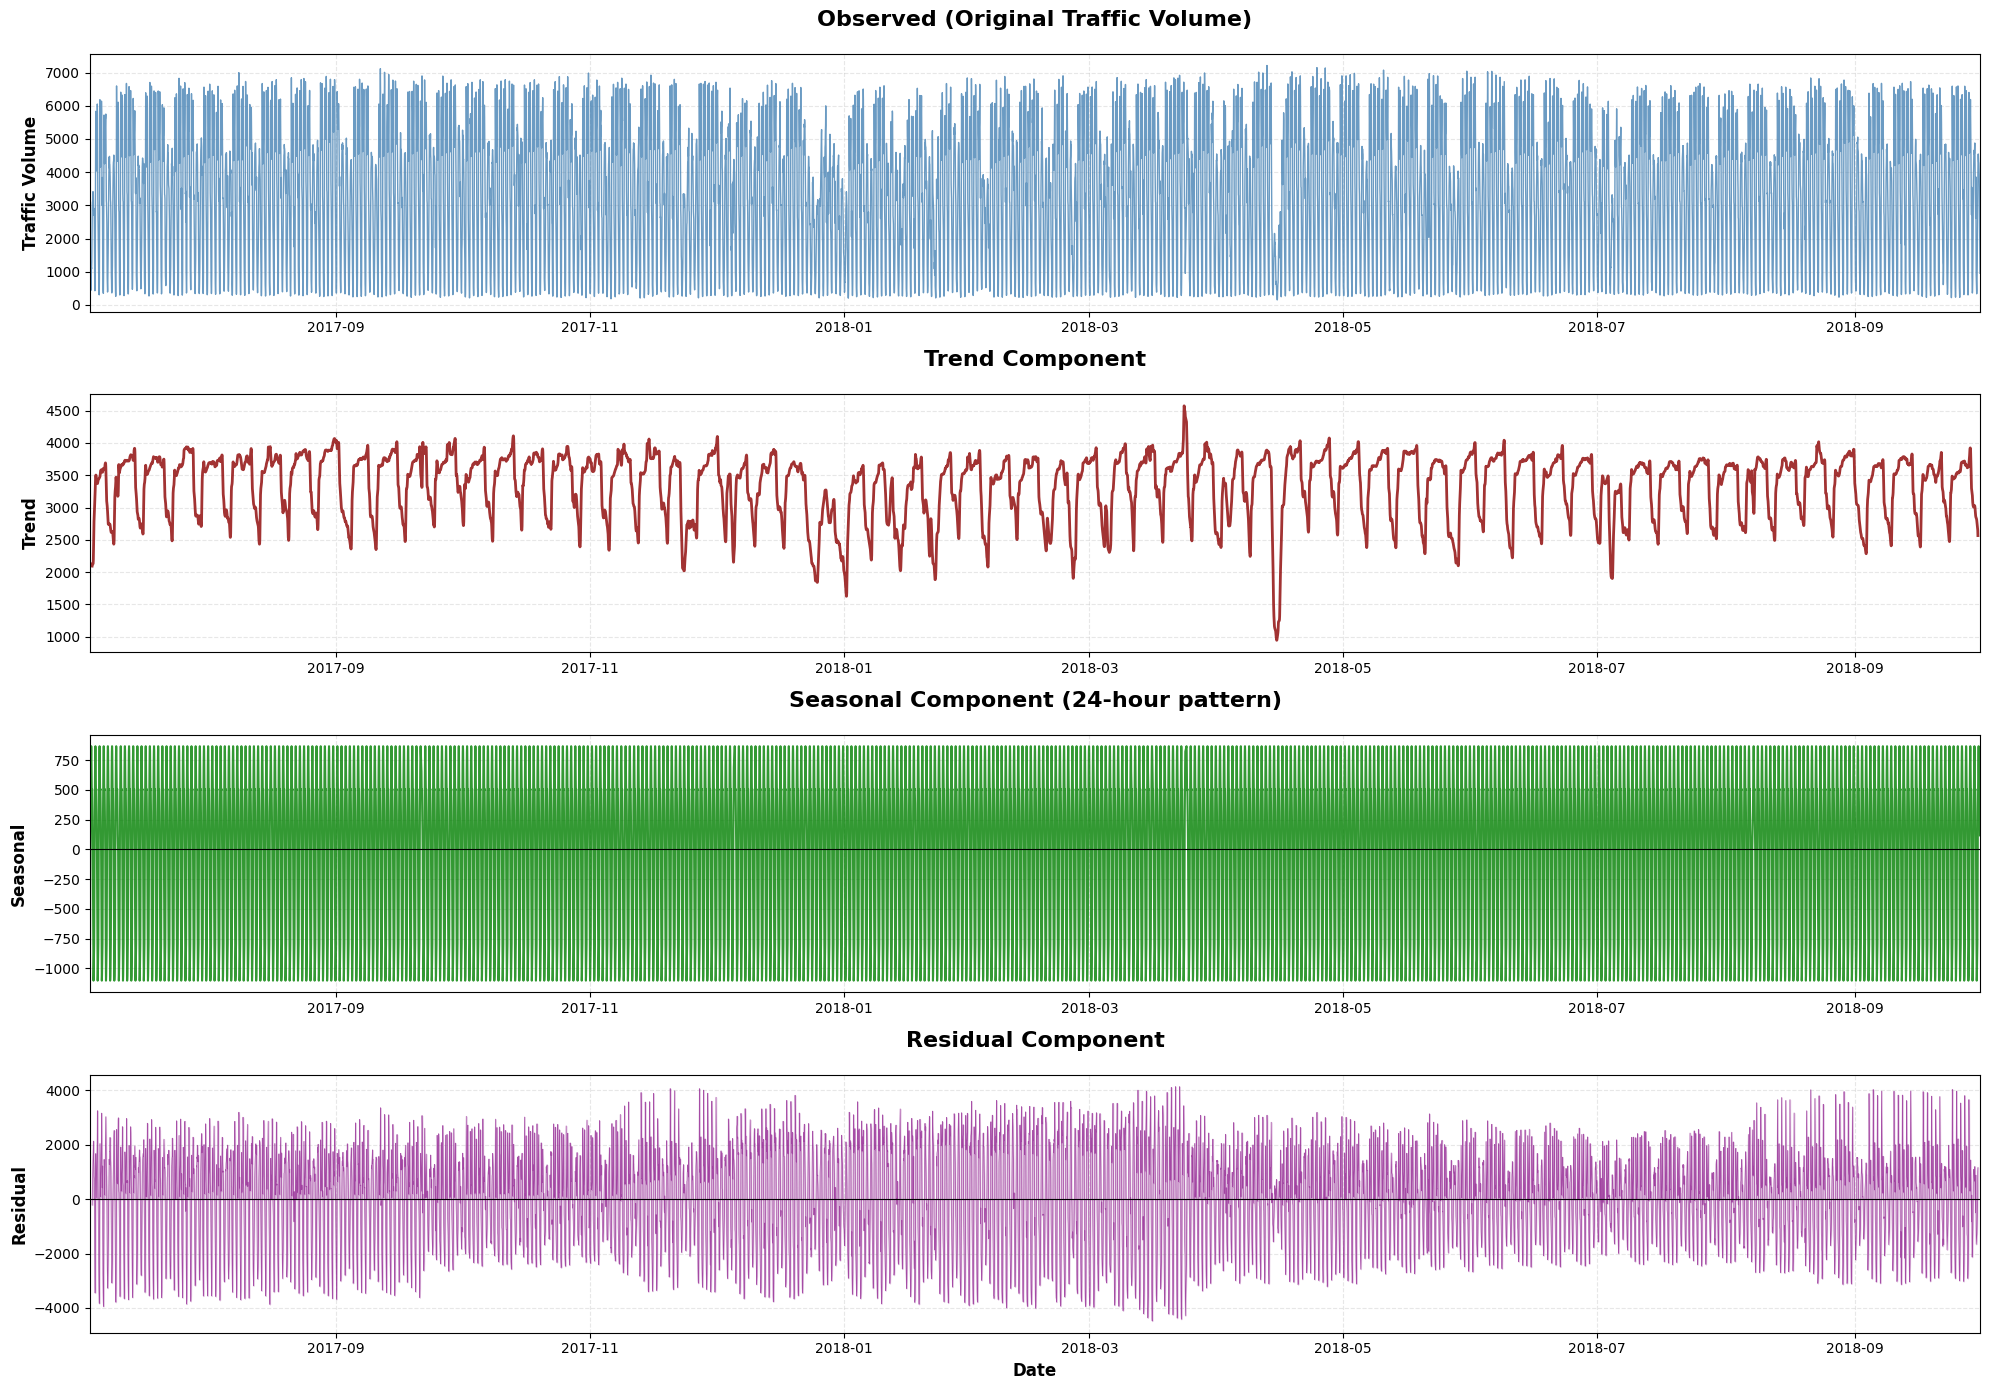

In [24]:
# Manual decomposition visualization
decomposition = seasonal_decompose(df_ts['traffic_volume'], model='additive', period=24)

# Extract components
observed = df_ts['traffic_volume']
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Create elaborate visualization
fig, axes = plt.subplots(4, 1, figsize=(20, 14))

# 1. Observed (Original Data)
axes[0].plot(observed, linewidth=1, color='steelblue', alpha=0.8)
axes[0].set_title('Observed (Original Traffic Volume)', fontsize=16, fontweight='bold', pad=20)
axes[0].set_ylabel('Traffic Volume', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xlim(observed.index[0], observed.index[-1])

# 2. Trend
axes[1].plot(trend, linewidth=2, color='darkred', alpha=0.8)
axes[1].set_title('Trend Component', fontsize=16, fontweight='bold', pad=20)
axes[1].set_ylabel('Trend', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_xlim(observed.index[0], observed.index[-1])

# 3. Seasonal
axes[2].plot(seasonal, linewidth=1.5, color='green', alpha=0.8)
axes[2].set_title('Seasonal Component (24-hour pattern)', fontsize=16, fontweight='bold', pad=20)
axes[2].set_ylabel('Seasonal', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].set_xlim(observed.index[0], observed.index[-1])
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# 4. Residual
axes[3].plot(residual, linewidth=0.5, color='purple', alpha=0.6)
axes[3].set_title('Residual Component', fontsize=16, fontweight='bold', pad=20)
axes[3].set_ylabel('Residual', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Date', fontsize=12, fontweight='bold')
axes[3].grid(True, alpha=0.3, linestyle='--')
axes[3].set_xlim(observed.index[0], observed.index[-1])
axes[3].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[3].fill_between(residual.index, residual, alpha=0.2, color='purple')

plt.tight_layout()
plt.show()

Cek anomali trend

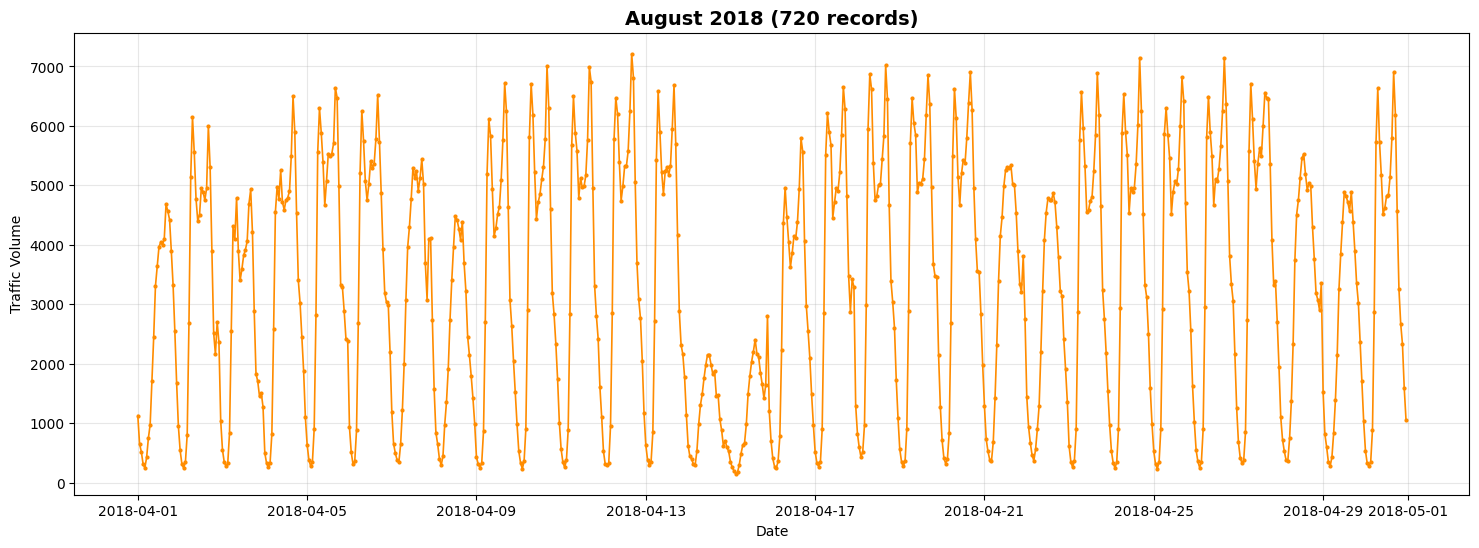

In [25]:
plt.figure(figsize=(18, 6))
month_data = df_ts.loc['2018-04']
plt.plot(month_data["traffic_volume"], linewidth=1.2, color='darkorange', marker='o', markersize=2)
plt.title(f'August 2018 ({len(month_data):,} records)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Traffic Volume')
plt.grid(True, alpha=0.3)
plt.show()

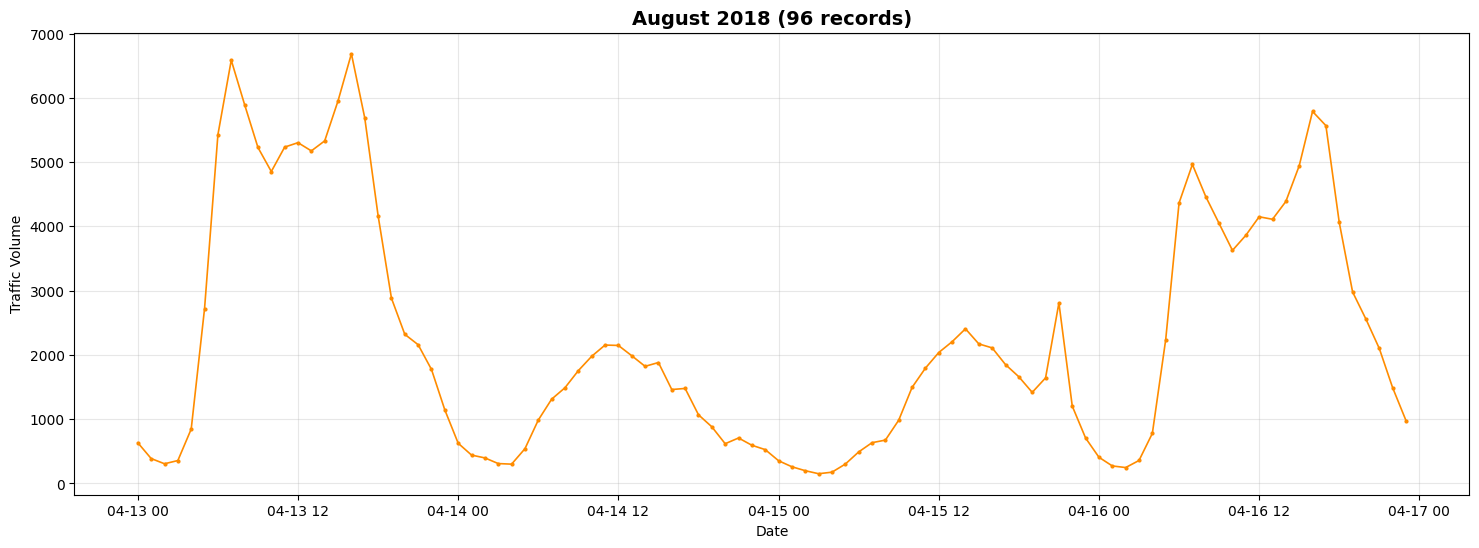

In [26]:
plt.figure(figsize=(18, 6))
month_data = df_ts.loc['2018-04-13':'2018-04-16']
plt.plot(month_data["traffic_volume"], linewidth=1.2, color='darkorange', marker='o', markersize=2)
plt.title(f'August 2018 ({len(month_data):,} records)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Traffic Volume')
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
display(df_ts.loc['2018-04-13 00:00:00':'2018-04-16 23:00:00'])

# Filter for midnight times
filtered_data = df_ts.loc['2018-04-13 00:00:00':'2018-04-16 23:00:00']
midnight_data = filtered_data[filtered_data.index.hour == 0]
display(midnight_data)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume
date_time,,,,,,,,
2018-04-13 00:00:00,NaN,277.15,0.0,0.0,1,Clear,sky is clear,633
2018-04-13 01:00:00,NaN,276.65,0.0,0.0,90,Clouds,overcast clouds,387
2018-04-13 02:00:00,NaN,276.42,0.0,0.0,1,Clear,sky is clear,306
2018-04-13 03:00:00,NaN,276.22,0.0,0.0,1,Clear,sky is clear,356
2018-04-13 04:00:00,NaN,275.87,0.0,0.0,1,Clear,sky is clear,846
...,...,...,...,...,...,...,...,...
2018-04-16 19:00:00,NaN,275.23,0.0,0.0,75,Clouds,broken clouds,2979
2018-04-16 20:00:00,NaN,274.65,0.0,0.0,90,Clouds,overcast clouds,2556
2018-04-16 21:00:00,NaN,274.44,0.0,0.0,90,Clouds,overcast clouds,2100


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume
date_time,,,,,,,,
2018-04-13,NaN,277.15,0.0,0.0,1,Clear,sky is clear,633
2018-04-14,NaN,272.73,0.0,0.0,90,Snow,snow,625
2018-04-15,NaN,268.02,0.0,0.0,90,Snow,light snow,353
2018-04-16,NaN,268.79,0.0,0.0,90,Snow,light snow,407


Anomali tidak terjadi pada hari Holiday

### Time Series Plot for Temp, Cloud, Rain vs Traffic volume

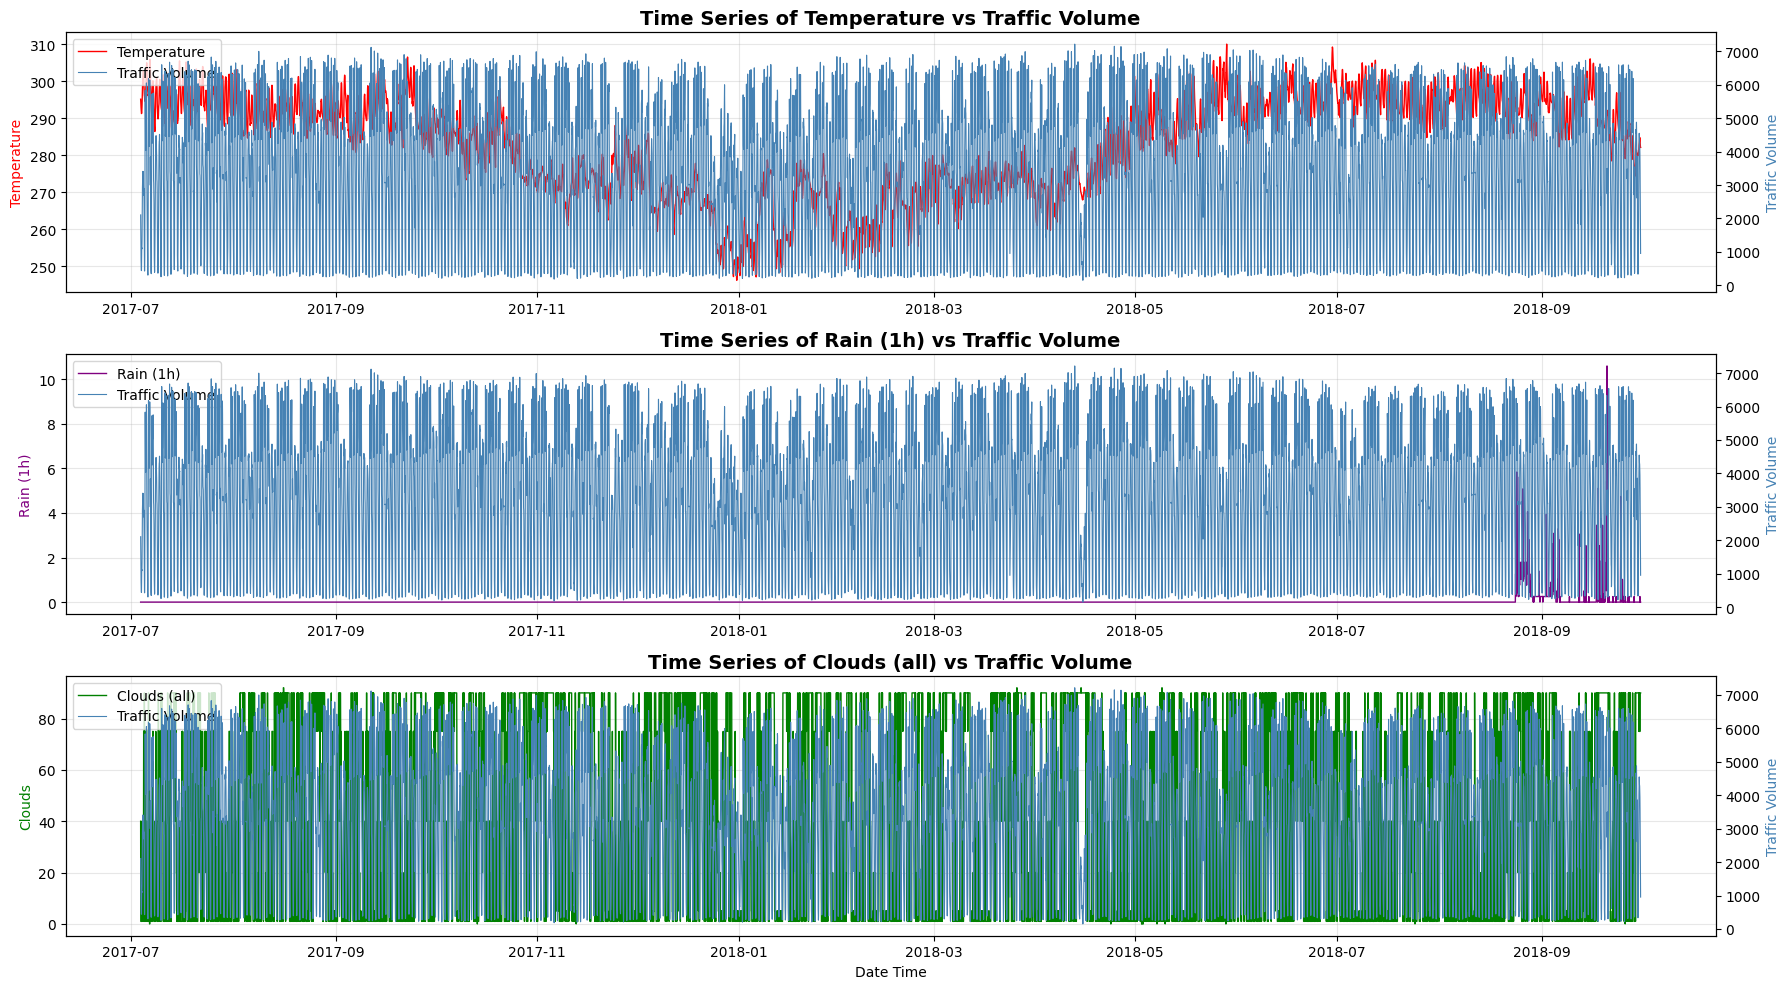

In [28]:
df_ts_weather = df_ts.copy()

# Config
weather_vars = [
    ('temp', 'Temperature', 'Temperature', 'red'),
    ('rain_1h', 'Rain (1h)', 'Rain (1h)', 'purple'),
    ('clouds_all', 'Clouds (all)', 'Clouds', 'green')
]

plt.figure(figsize=(18, 10))

for i, (col, title, ylabel, color) in enumerate(weather_vars, 1):
    plt.subplot(3, 1, i)
    ax1 = plt.gca()
    ax2 = ax1.twinx()

    # Plot weather variable and traffic volume
    ax1.plot(df_ts_weather[col], label=title, color=color, linewidth=1)
    ax2.plot(df_ts["traffic_volume"], label='Traffic Volume', linewidth=0.8, color='steelblue')

    ax1.set_title(f'Time Series of {title} vs Traffic Volume', fontsize=14, fontweight='bold')
    ax1.set_ylabel(ylabel, color=color)
    ax2.set_ylabel('Traffic Volume', color='steelblue')
    ax1.grid(True, alpha=0.3)

    if i == 3:
        ax1.set_xlabel('Date Time')

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

Zoom in to 3 Month 2018-06:2018-08


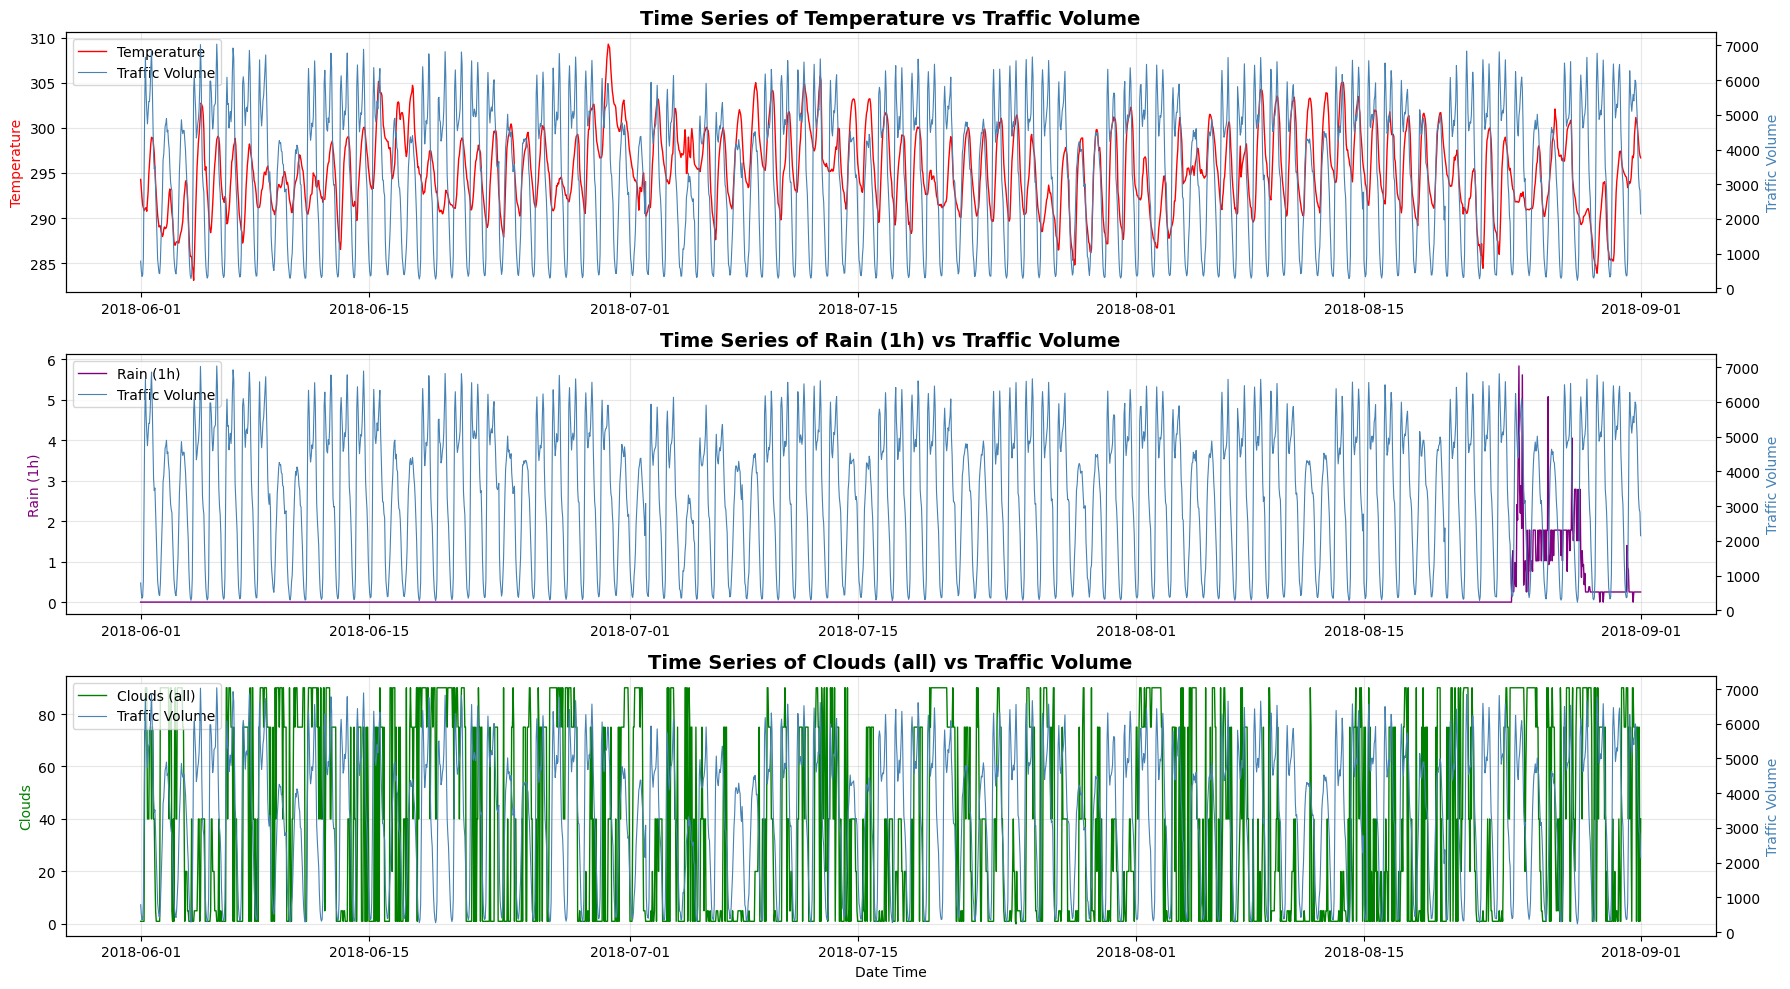

In [29]:
# Zoom in to 3 Month
print("Zoom in to 3 Month 2018-06:2018-08")
df_ts_weather_week = df_ts_weather.loc['2018-06' : '2018-08']

# Config
weather_vars = [
    ('temp', 'Temperature', 'Temperature', 'red'),
    ('rain_1h', 'Rain (1h)', 'Rain (1h)', 'purple'),
    ('clouds_all', 'Clouds (all)', 'Clouds', 'green')
]

plt.figure(figsize=(18, 10))

for i, (col, title, ylabel, color) in enumerate(weather_vars, 1):
    plt.subplot(3, 1, i)
    ax1 = plt.gca()
    ax2 = ax1.twinx()

    # Plot weather variable and traffic volume
    ax1.plot(df_ts_weather_week[col], label=title, color=color, linewidth=1)
    ax2.plot(df_ts_weather_week["traffic_volume"], label='Traffic Volume', linewidth=0.8, color='steelblue')

    ax1.set_title(f'Time Series of {title} vs Traffic Volume', fontsize=14, fontweight='bold')
    ax1.set_ylabel(ylabel, color=color)
    ax2.set_ylabel('Traffic Volume', color='steelblue')
    ax1.grid(True, alpha=0.3)

    if i == 3:
        ax1.set_xlabel('Date Time')

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

Zoom in to 1 Month 2018-08


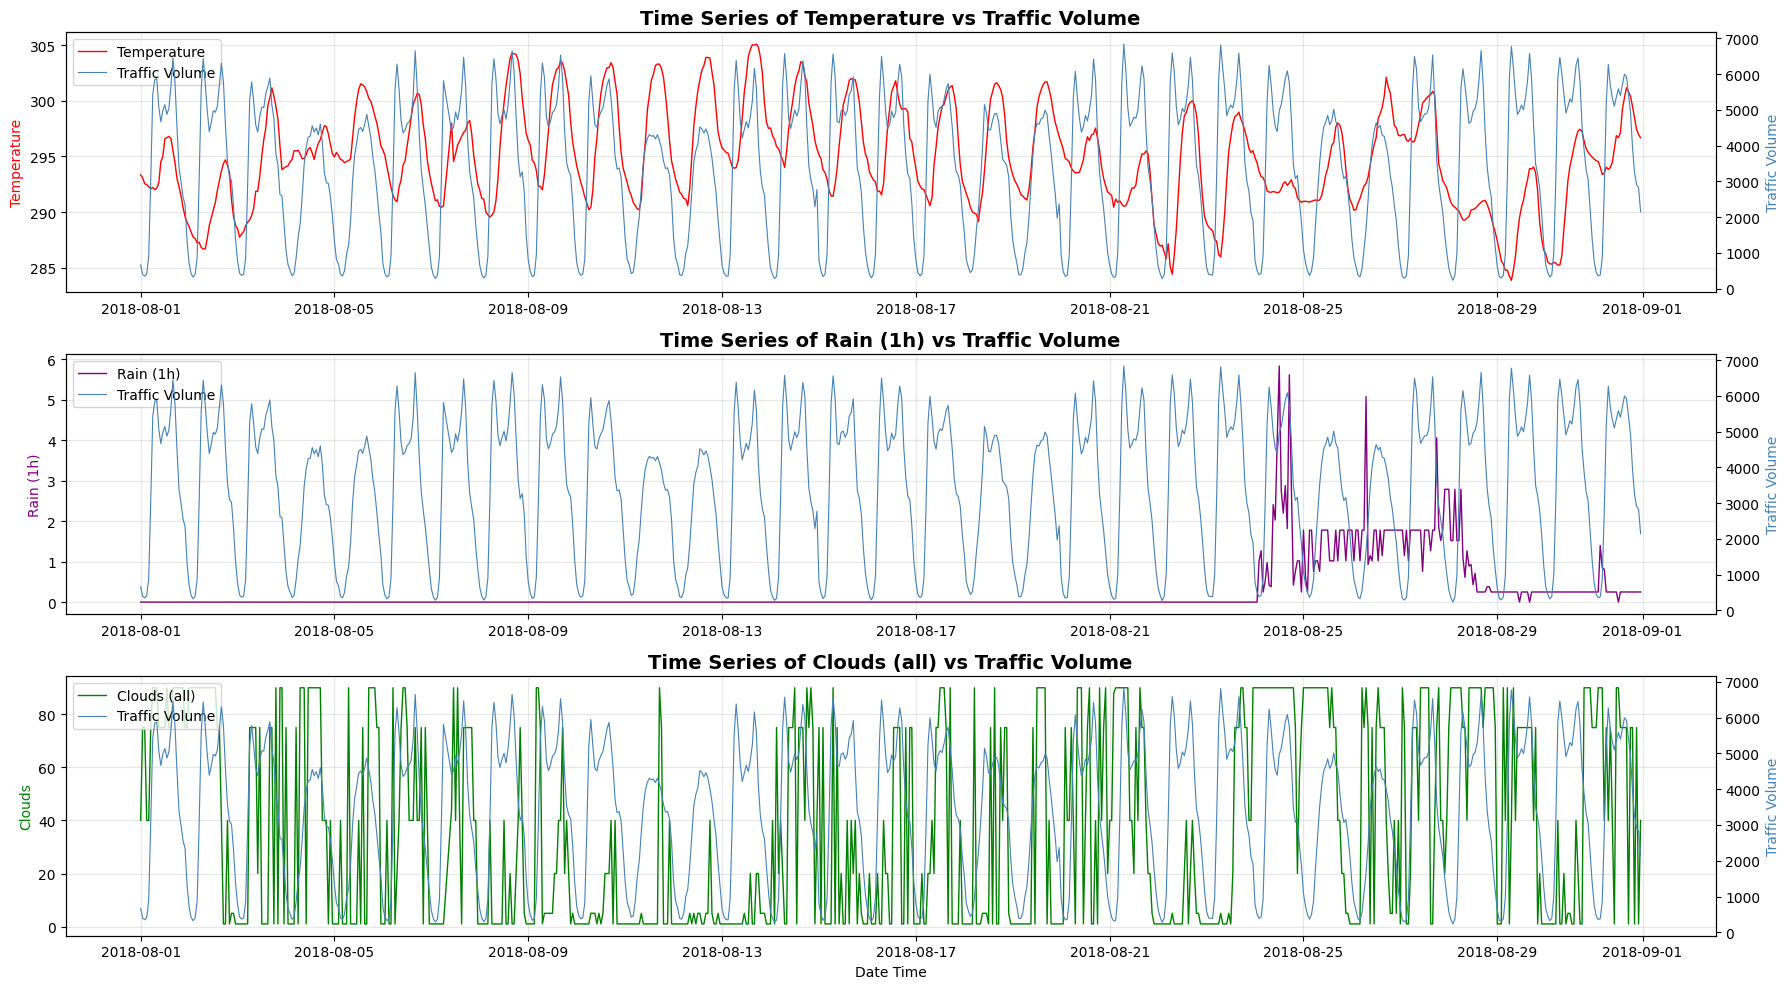

In [30]:
# Zoom in to 1 Month
print("Zoom in to 1 Month 2018-08")
df_ts_weather_week = df_ts_weather.loc['2018-08']

# Config
weather_vars = [
    ('temp', 'Temperature', 'Temperature', 'red'),
    ('rain_1h', 'Rain (1h)', 'Rain (1h)', 'purple'),
    ('clouds_all', 'Clouds (all)', 'Clouds', 'green')
]

plt.figure(figsize=(18, 10))

for i, (col, title, ylabel, color) in enumerate(weather_vars, 1):
    plt.subplot(3, 1, i)
    ax1 = plt.gca()
    ax2 = ax1.twinx()

    # Plot weather variable and traffic volume
    ax1.plot(df_ts_weather_week[col], label=title, color=color, linewidth=1)
    ax2.plot(df_ts_weather_week["traffic_volume"], label='Traffic Volume', linewidth=0.8, color='steelblue')

    ax1.set_title(f'Time Series of {title} vs Traffic Volume', fontsize=14, fontweight='bold')
    ax1.set_ylabel(ylabel, color=color)
    ax2.set_ylabel('Traffic Volume', color='steelblue')
    ax1.grid(True, alpha=0.3)

    if i == 3:
        ax1.set_xlabel('Date Time')

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

Zoom in to 1 Week 2018-08-20:2018-08-27


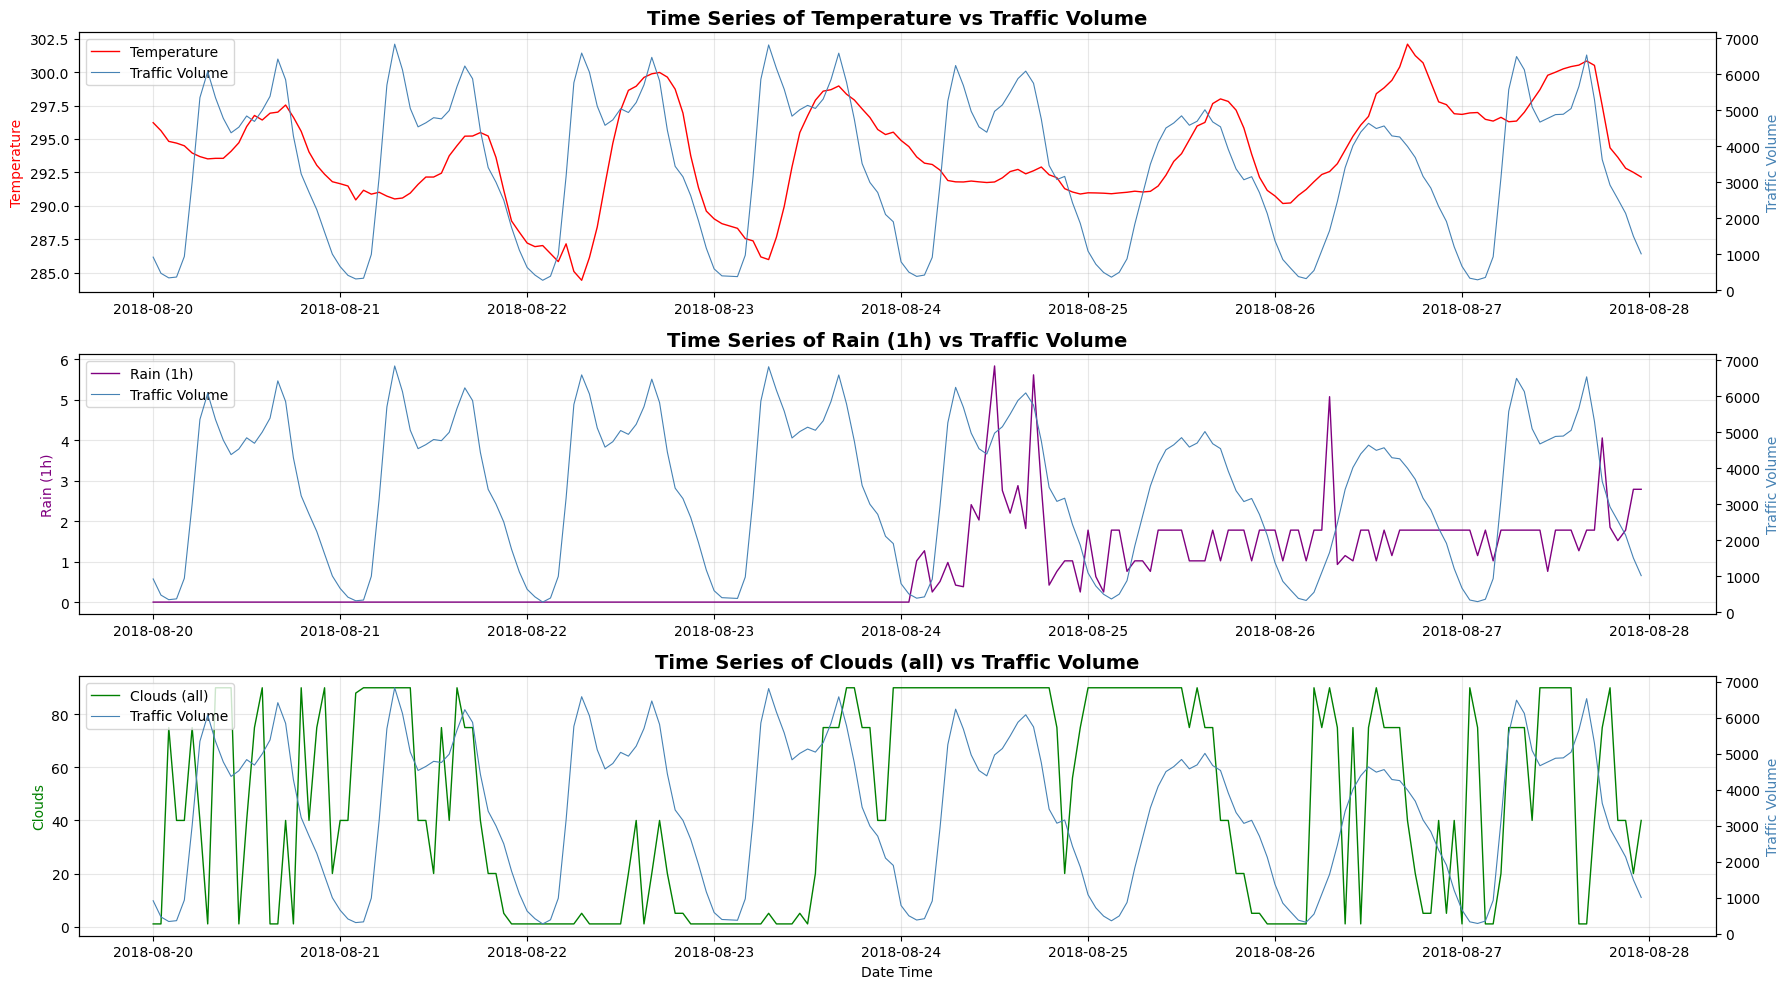

In [31]:
# Zoom in to 1 Week
print("Zoom in to 1 Week 2018-08-20:2018-08-27")
df_ts_weather_week = df_ts_weather.loc['2018-08-20':'2018-08-27']

# Config
weather_vars = [
    ('temp', 'Temperature', 'Temperature', 'red'),
    ('rain_1h', 'Rain (1h)', 'Rain (1h)', 'purple'),
    ('clouds_all', 'Clouds (all)', 'Clouds', 'green')
]

plt.figure(figsize=(18, 10))

for i, (col, title, ylabel, color) in enumerate(weather_vars, 1):
    plt.subplot(3, 1, i)
    ax1 = plt.gca()
    ax2 = ax1.twinx()

    # Plot weather variable and traffic volume
    ax1.plot(df_ts_weather_week[col], label=title, color=color, linewidth=1)
    ax2.plot(df_ts_weather_week["traffic_volume"], label='Traffic Volume', linewidth=0.8, color='steelblue')

    ax1.set_title(f'Time Series of {title} vs Traffic Volume', fontsize=14, fontweight='bold')
    ax1.set_ylabel(ylabel, color=color)
    ax2.set_ylabel('Traffic Volume', color='steelblue')
    ax1.grid(True, alpha=0.3)

    if i == 3:
        ax1.set_xlabel('Date Time')

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

## Time Extraction for EDA

In [32]:
# Menggunakan nodup agar weight data tepat
df_te = df_nodup.copy()
df_te['date_time'] = pd.to_datetime(df_te['date_time'])

# Extract time components
df_te['hour'] = df_te['date_time'].dt.hour
df_te['day_of_week'] = df_te['date_time'].dt.day_name()
df_te['is_weekend'] = df_te['date_time'].dt.dayofweek >= 5

df_te.head(5)

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,is_weekend
35055,NaN,295.16,0.0,0.0,40,Clouds,scattered clouds,2017-07-03 22:00:00,2106,22,Monday,False
35056,NaN,294.56,0.0,0.0,1,Clear,sky is clear,2017-07-03 23:00:00,1606,23,Monday,False
35057,Independence Day,293.41,0.0,0.0,1,Clear,sky is clear,2017-07-04 00:00:00,1225,0,Tuesday,False
35058,NaN,292.89,0.0,0.0,1,Clear,sky is clear,2017-07-04 01:00:00,746,1,Tuesday,False
35059,NaN,292.42,0.0,0.0,1,Clear,sky is clear,2017-07-04 02:00:00,592,2,Tuesday,False


## Traffic Distribution - Time Extraction

Boxplot Volume Traffic perhari

/tmp/ipython-input-3489087452.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_of_week', y='traffic_volume', data=df_te, order=order, palette='viridis',showmeans=True,


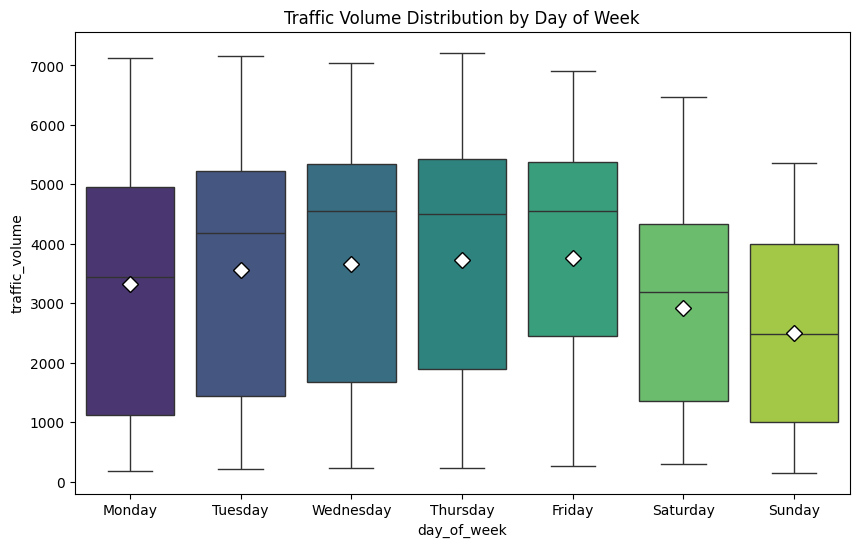

In [33]:
plt.figure(figsize=(10, 6))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(x='day_of_week', y='traffic_volume', data=df_te, order=order, palette='viridis',showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize": "8"})
plt.title('Traffic Volume Distribution by Day of Week')
plt.show()

boxplot volume traffic antara weekend / bukan weekend

/tmp/ipython-input-3602670469.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_weekend', y='traffic_volume', data=df_te, palette='viridis',showmeans=True,


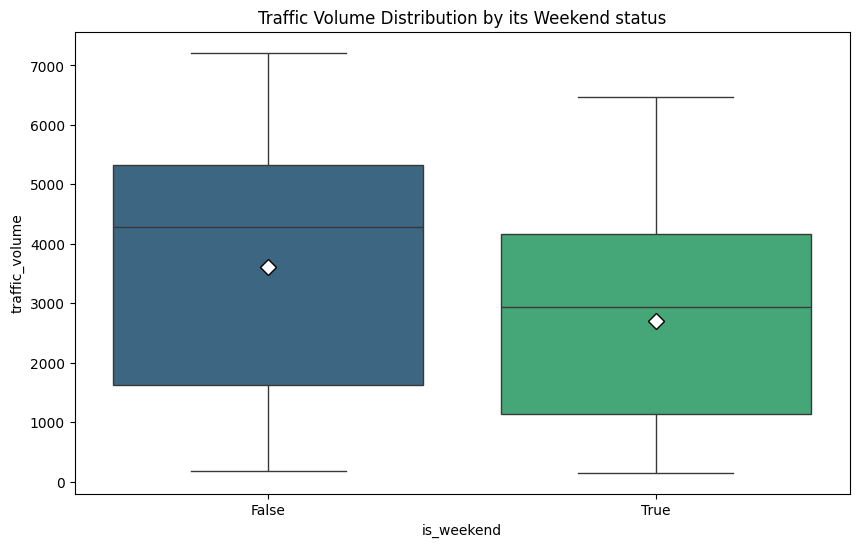

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_weekend', y='traffic_volume', data=df_te, palette='viridis',showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize": "8"})
plt.title('Traffic Volume Distribution by its Weekend status')
plt.show()

Heatmap avarage traffic vol -> bisa untuk mencari rush hour

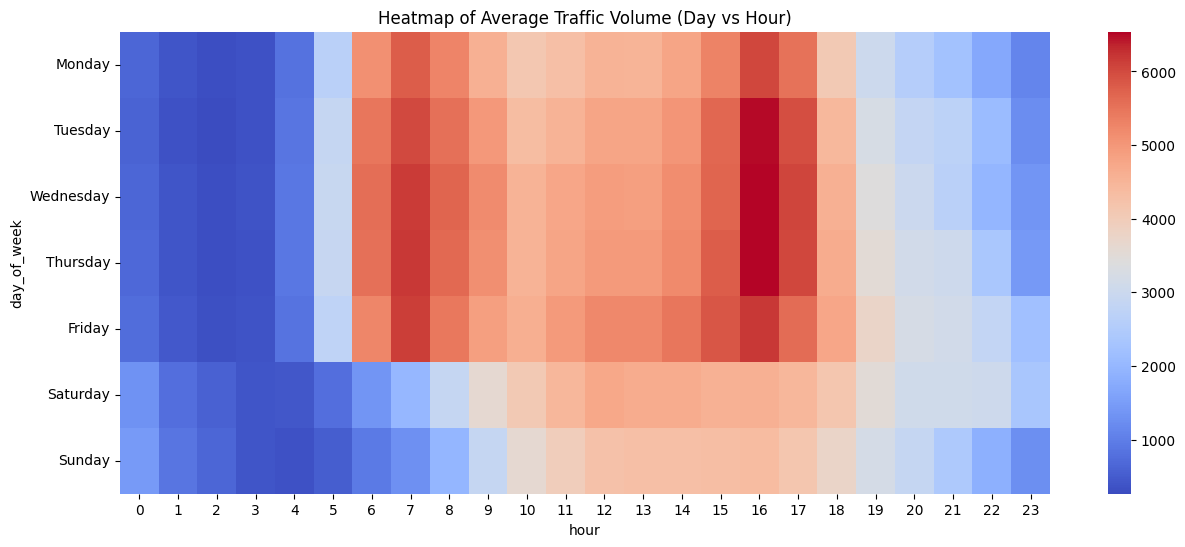

In [35]:
pivot_table = df_te.pivot_table(values='traffic_volume', index='day_of_week', columns='hour', aggfunc='mean')
plt.figure(figsize=(15, 6))
sns.heatmap(pivot_table.reindex(order), cmap='coolwarm', annot=False)
plt.title('Heatmap of Average Traffic Volume (Day vs Hour)')
plt.show()

/tmp/ipython-input-100195348.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hour', y='traffic_volume', data=df_te, palette='viridis',showmeans=True,


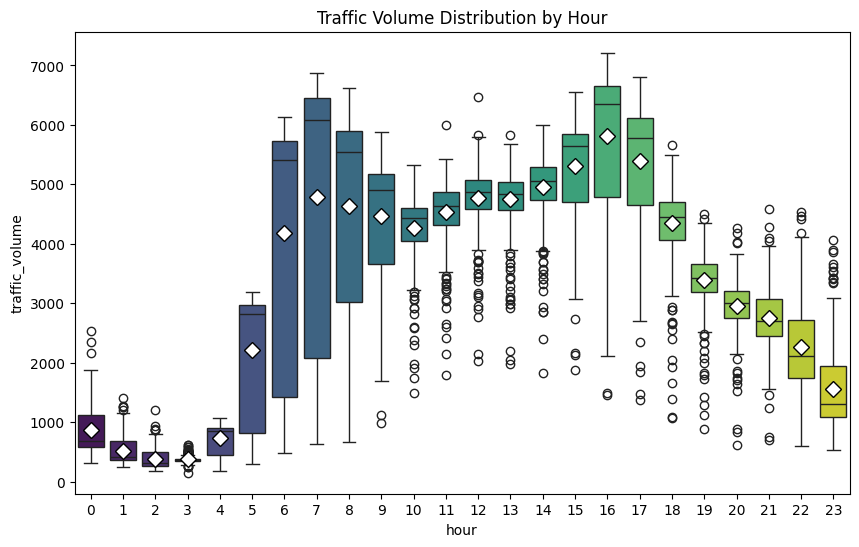

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='hour', y='traffic_volume', data=df_te, palette='viridis',showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize": "8"})
plt.title('Traffic Volume Distribution by Hour')
plt.show()

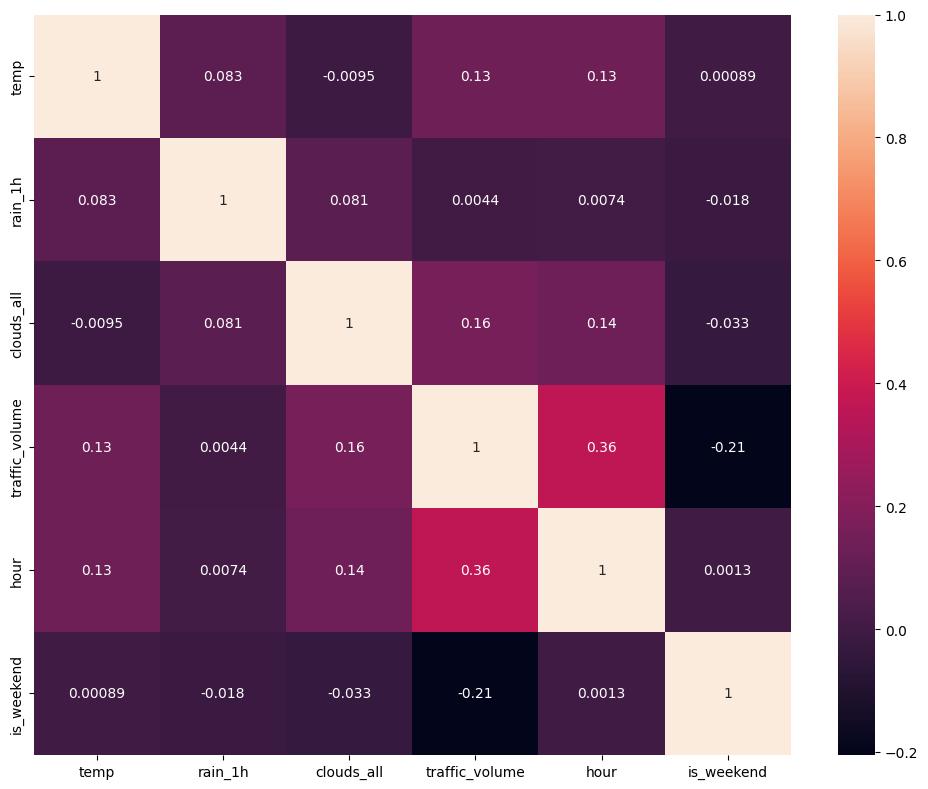

In [37]:
# exclude snow_1h
corr_num_col = ['temp', 'rain_1h', 'clouds_all', 'traffic_volume','hour','is_weekend' ]

# Calculate correlation matrix
correlation_matrix = df_te[corr_num_col].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True)
plt.tight_layout()
plt.show()

# Preprocessing


1. Drop duplicate
2. Drop snow_1h
3. interpolasi missing value (34)
4. ganti NaN holiday ke None Object
5. ganti suhu ke celcius


In [38]:
df_preprocess = df.copy()

# drop duplicate
df_preprocess = df_preprocess.drop_duplicates(subset='date_time', keep='first')

# drop snow
df_preprocess = df_preprocess.drop(columns=['snow_1h'])

# Adding in missing value (34)
row_count0 = len(df_preprocess)
df_preprocess['date_time'] = pd.to_datetime(df_preprocess['date_time'])
df_preprocess = df_preprocess.set_index('date_time')
df_preprocess = df_preprocess.resample('h').asfreq()

## Numeric column (interpolate : Time-weighted Interpolation)
numeric_columns = ['temp', 'rain_1h', 'clouds_all', 'traffic_volume']
df_preprocess[numeric_columns] = df_preprocess[numeric_columns].interpolate(method='time')

## Categorical column (interpolate ffill)
categorical_columns = ['weather_description', 'weather_main']
df_preprocess[categorical_columns] = df_preprocess[categorical_columns].ffill()

## from EDA we know that No gaps are detected that are in the 00:00 (that means we can fill all missing value  of holiday to NaN)
df_preprocess['holiday'] = df_preprocess['holiday'].fillna("None")
df_preprocess = df_preprocess.reset_index()

row_count1 = len(df_preprocess)
diff = row_count1 - row_count0

print(f"Original Rows: {row_count0}\nNew Rows:      {row_count1}\nRows Added:    {diff}")
print("✅ SUCCESS: Exactly 34 missing hours were filled." if diff == 34 else f"⚠️ WARNING: Expected 34, but added {diff}. Check for duplicates in original data.")

# re-calculate temp to celcius (kelvin to celcius)
df_preprocess['temp'] = df_preprocess['temp'] - 273.15

df_preprocess.head(5)

Original Rows: 10864
New Rows:      10898
Rows Added:    34
✅ SUCCESS: Exactly 34 missing hours were filled.


,date_time,holiday,temp,rain_1h,clouds_all,weather_main,weather_description,traffic_volume
0,2017-07-03 22:00:00,None,22.01,0.0,40.0,Clouds,scattered clouds,2106.0
1,2017-07-03 23:00:00,None,21.41,0.0,1.0,Clear,sky is clear,1606.0
2,2017-07-04 00:00:00,Independence Day,20.26,0.0,1.0,Clear,sky is clear,1225.0
3,2017-07-04 01:00:00,None,19.74,0.0,1.0,Clear,sky is clear,746.0
4,2017-07-04 02:00:00,None,19.27,0.0,1.0,Clear,sky is clear,592.0


# Feature Engineer

1. time extraction : hour, day, is_weekend
2. holiday handling : is_holiday

In [39]:
df_feature = df_preprocess.copy()

# time feature
df_feature['hour'] = df_feature['date_time'].dt.hour
df_feature['day_of_week'] = df_feature['date_time'].dt.dayofweek+1
df_feature['is_weekend'] = (df_feature['date_time'].dt.dayofweek >= 5).astype(int)

# holiday handle nan value, change to is holiday and mark all the hour
holiday_dates = df_feature.loc[(df_feature['holiday']!= 'None'),'date_time'].dt.date.unique()
df_feature['is_holiday'] = (df_feature['date_time'].dt.date.isin(holiday_dates)).astype(int)
df_feature = df_feature.drop(columns=['holiday'])

df_feature.head(5)

,date_time,temp,rain_1h,clouds_all,weather_main,weather_description,traffic_volume,hour,day_of_week,is_weekend,is_holiday
0,2017-07-03 22:00:00,22.01,0.0,40.0,Clouds,scattered clouds,2106.0,22,1,0,0
1,2017-07-03 23:00:00,21.41,0.0,1.0,Clear,sky is clear,1606.0,23,1,0,0
2,2017-07-04 00:00:00,20.26,0.0,1.0,Clear,sky is clear,1225.0,0,2,0,1
3,2017-07-04 01:00:00,19.74,0.0,1.0,Clear,sky is clear,746.0,1,2,0,1
4,2017-07-04 02:00:00,19.27,0.0,1.0,Clear,sky is clear,592.0,2,2,0,1


## Cyclical Encoding

In [40]:
# 1. Encode Hour (Period = 24 hours)
df_feature['hour_sin'] = np.sin(2 * np.pi * df_feature['hour'] / 24)
df_feature['hour_cos'] = np.cos(2 * np.pi * df_feature['hour'] / 24)

# 2. Encode Day of Week (Period = 7 days)
df_feature['day_sin'] = np.sin(2 * np.pi * df_feature['day_of_week'] / 7)
df_feature['day_cos'] = np.cos(2 * np.pi * df_feature['day_of_week'] / 7)

# 3. drop the hour and day of week
# df_feature = df_feature.drop(columns=['hour', 'day_of_week'])

df_feature.head(5)

,date_time,temp,rain_1h,clouds_all,weather_main,weather_description,traffic_volume,hour,day_of_week,is_weekend,is_holiday,hour_sin,hour_cos,day_sin,day_cos
0,2017-07-03 22:00:00,22.01,0.0,40.0,Clouds,scattered clouds,2106.0,22,1,0,0,-0.500000,0.866025,0.781831,0.623490
1,2017-07-03 23:00:00,21.41,0.0,1.0,Clear,sky is clear,1606.0,23,1,0,0,-0.258819,0.965926,0.781831,0.623490
2,2017-07-04 00:00:00,20.26,0.0,1.0,Clear,sky is clear,1225.0,0,2,0,1,0.000000,1.000000,0.974928,-0.222521
3,2017-07-04 01:00:00,19.74,0.0,1.0,Clear,sky is clear,746.0,1,2,0,1,0.258819,0.965926,0.974928,-0.222521
4,2017-07-04 02:00:00,19.27,0.0,1.0,Clear,sky is clear,592.0,2,2,0,1,0.500000,0.866025,0.974928,-0.222521


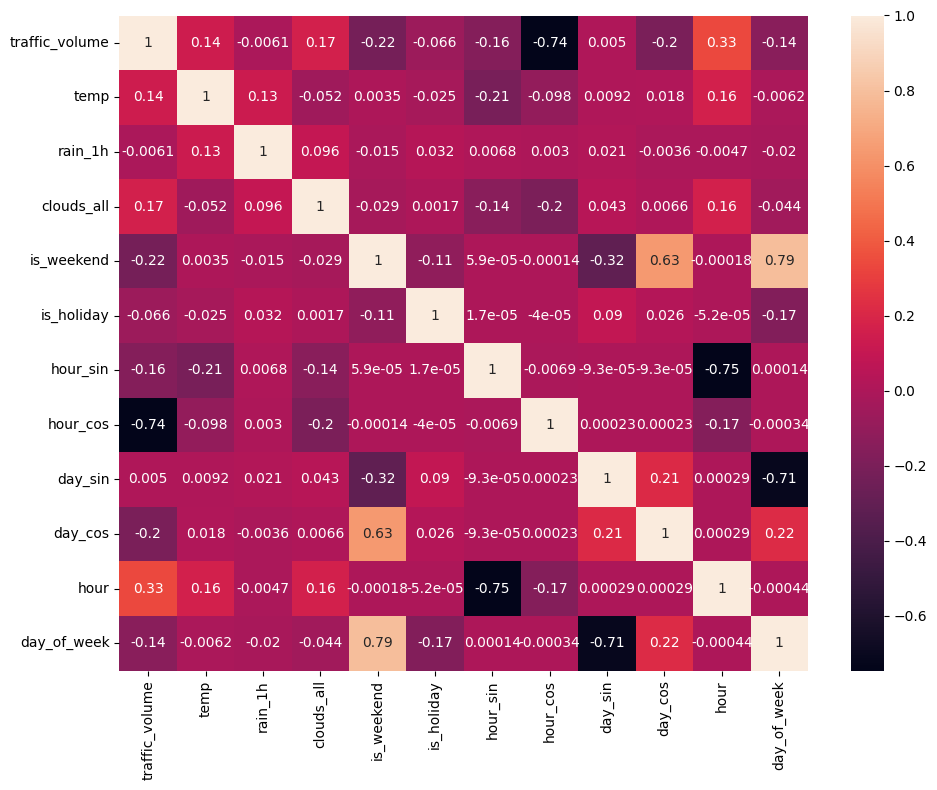

In [41]:
corr_num_col = ['traffic_volume','temp', 'rain_1h', 'clouds_all','is_weekend','is_holiday','hour_sin','hour_cos','day_sin', 'day_cos','hour', 'day_of_week' ]

# Calculate correlation matrix
correlation_matrix = df_feature[corr_num_col].corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True)
plt.tight_layout()
plt.show()

## Traffic Lag Feature

In [42]:
# Create lag features for traffic_volume
df_feature['traffic_lag_1'] = df_feature['traffic_volume'].shift(1)
df_feature['traffic_lag_2'] = df_feature['traffic_volume'].shift(2)
df_feature['traffic_lag_3'] = df_feature['traffic_volume'].shift(3)
df_feature['traffic_lag_24'] = df_feature['traffic_volume'].shift(24)
df_feature['traffic_lag_168'] = df_feature['traffic_volume'].shift(24 * 7)  # 1 week = 168 hours


In [43]:
df_feature = df_feature.drop(columns=['hour', 'day_of_week', 'date_time', 'weather_description', 'weather_main'])
df_feature_clearNan = df_feature.dropna()

In [44]:
df_ready = df_feature_clearNan.copy()
df_ready.head()

,temp,rain_1h,clouds_all,traffic_volume,is_weekend,is_holiday,hour_sin,hour_cos,day_sin,day_cos,traffic_lag_1,traffic_lag_2,traffic_lag_3,traffic_lag_24,traffic_lag_168
168,23.41,0.0,40.0,2038.0,0,0,-0.500000,0.866025,0.781831,0.623490,2804.0,2853.0,3220.0,1722.0,2106.0
169,21.07,0.0,1.0,1183.0,0,0,-0.258819,0.965926,0.781831,0.623490,2038.0,2804.0,2853.0,1172.0,1606.0
170,20.28,0.0,1.0,674.0,0,0,0.000000,1.000000,0.974928,-0.222521,1183.0,2038.0,2804.0,649.0,1225.0
171,18.95,0.0,1.0,392.0,0,0,0.258819,0.965926,0.974928,-0.222521,674.0,1183.0,2038.0,397.0,746.0
172,17.94,0.0,1.0,299.0,0,0,0.500000,0.866025,0.974928,-0.222521,392.0,674.0,1183.0,257.0,592.0


# Model Training

Evaluation :
1. MAE  (Mean Absolute Error)
2. RMSE (Root Mean Squared Error)
3. R2   
4. MASE (Mean Absolute Scaled Error)

## Data Split


In [45]:
n = len(df_ready)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

# Slice the dataframe (Strict Temporal Order)
train_df = df_ready.iloc[:train_end]
val_df = df_ready.iloc[train_end:val_end]
test_df = df_ready.iloc[val_end:]

print(f"Train samples: {len(train_df)}")
print(f"Val samples:   {len(val_df)}")
print(f"Test samples:  {len(test_df)}")

Train samples: 7510
Val samples:   1610
Test samples:  1610


## Base Model



### Seasonal Naive


In [46]:
# We need the full dataset to easily grab "yesterday's" data for the first day of the test set
# We take the column, shift it by 24, and THEN slice the test portion.
full_traffic = df_ready['traffic_volume']

# Shift by 24 hours (Lag 24)
# values at index `t` become values at index `t+24`
naive_preds_series = full_traffic.shift(24)

# Slice strictly to the Test period
test_df_naive = test_df.copy()
y_naive_pred = naive_preds_series.iloc[val_end:]
y_test_actual_naive = test_df_naive['traffic_volume']

# Calculate Scores
mae_naive = mean_absolute_error(y_test_actual_naive, y_naive_pred)
rmse_naive = np.sqrt(mean_squared_error(y_test_actual_naive, y_naive_pred))
r2_naive = r2_score(y_test_actual_naive, y_naive_pred)

print("\n=== BASELINE 1: SEASONAL NAIVE ===")
print(f"MAE :   {mae_naive:.2f} cars")
print(f"RMSE:   {rmse_naive:.2f} cars")
print(f"R2  :   {r2_naive:.4f}")
print("----------------------------------")


=== BASELINE 1: SEASONAL NAIVE ===
MAE :   486.01 cars
RMSE:   932.21 cars
R2  :   0.7694
----------------------------------


### Prophet


In [47]:
# Reset index if your date is in the index & rename col
df_prophet = df_ready.reset_index()
df_prophet = df_prophet.rename(columns={
    df_prophet.columns[0]: 'ds',
    'traffic_volume': 'y'
})

# 3. Ensure 'ds' is real datetime
if not np.issubdtype(df_prophet['ds'].dtype, np.datetime64):
    df_prophet['ds'] = pd.date_range(start='2017-07-03 22:00:00', periods=len(df_prophet), freq='H')

# 4. Split Train/Test (Strict Temporal Split)
n = len(df_prophet)
train_end_prophet = int(n * 0.85)
train_df_prophet = df_prophet.iloc[:train_end_prophet]
test_df_prophet = df_prophet.iloc[train_end_prophet:]

#5. model
model_prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=0.05
)

# Add regessor to propthet input only traffic_lag_24 and 168 so it doesnt look into the future data
for col in ['rain_1h', 'temp', 'is_holiday', 'is_weekend', 'traffic_lag_24', 'traffic_lag_168']:
  model_prophet.add_regressor(col)

model_prophet.fit(train_df_prophet)
forecast_naive = model_prophet.predict(test_df_prophet)
predictions = forecast_naive['yhat'].values
actuals = test_df_prophet['y'].values

# Metric
mae_prophet = mean_absolute_error(actuals, predictions)
rmse_prophet = np.sqrt(mean_squared_error(actuals, predictions))
r2_prophet = r2_score(actuals, predictions)

print("=== PROPHET BASELINE RESULTS ===")
print(f"MAE   :   {mae_prophet:.2f}")
print(f"RMSE  :   {rmse_prophet:.2f}")
print(f"R2    :   {r2_prophet:.4f}")
print("----------------------------------")

/tmp/ipython-input-3618903515.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_prophet['ds'] = pd.date_range(start='2017-07-03 22:00:00', periods=len(df_prophet), freq='H')


=== PROPHET BASELINE RESULTS ===
MAE   :   285.33
RMSE  :   442.06
R2    :   0.9481
----------------------------------


## Deep Learning

### LSTM Model

1. Cap the Train data so a high number doesnt mean its 100x stronger

2. 3D Tensor Transformation / Sliding Window

3. Deep Learning Model

4. Train Model

5. Prediction

6. Evaluation

In [48]:
# 1 : Only do fit on Train so it doesnt look into the future

target_scaler = MinMaxScaler()
feature_scaler = MinMaxScaler()
target_col = 'traffic_volume'
feature_cols = [c for c in train_df.columns if c != target_col]

def scale_xy(df, feature_cols, target_col, fit=False):
    X = df[feature_cols]
    y = df[[target_col]]
    if fit:
        X_scaled = feature_scaler.fit_transform(X)
        y_scaled = target_scaler.fit_transform(y)
    else:
        X_scaled = feature_scaler.transform(X)
        y_scaled = target_scaler.transform(y)
    return np.hstack((X_scaled, y_scaled))

# 1. TRAIN (fit scalers)
train_scaled_full = scale_xy(train_df, feature_cols, target_col, fit=True)
# 2. VALIDATION
val_scaled_full = scale_xy(val_df, feature_cols, target_col)
# 3. TEST
test_scaled_full = scale_xy(test_df, feature_cols, target_col)

In [49]:
# 2

def create_sequences(data, time_steps=24):
    X, y = [], []
    # Loop starting from 'time_steps' up to the end
    for i in range(len(data) - time_steps):
        # Input: The previous 'time_steps' rows (All columns)
        # Note: We use all columns (features + target) as input context
        X.append(data[i:(i + time_steps), :])

        # Target: The target column of the NEXT row
        # data[i + time_steps, -1] refers to the last column (traffic_volume)
        y.append(data[i + time_steps, -1])

    return np.array(X), np.array(y)

LOOK_BACK = 24

X_train, y_train = create_sequences(train_scaled_full, LOOK_BACK)

X_val, y_val = create_sequences(np.vstack([
    train_scaled_full[-LOOK_BACK:],  # last 24 hours of TRAIN
    val_scaled_full                  # full VALIDATION period
]), LOOK_BACK)

X_test, y_test = create_sequences(np.vstack([
    val_scaled_full[-LOOK_BACK:],  # last 24 hours of VALIDATION
    test_scaled_full                  # full TEST period
]), LOOK_BACK)

print(f"Input Shape (Batch, Steps, Features): {X_train.shape}")

Input Shape (Batch, Steps, Features): (7486, 24, 15)


In [50]:
# 3

n_features = X_train.shape[2]
model_LSTM = Sequential([
    # Layer 1: LSTM
    LSTM(64, return_sequences=True, input_shape=(LOOK_BACK, n_features)),
    Dropout(0.2), # Randomly drops 20% of neurons to force robustness

    # Layer 2: LSTM
    # return_sequences=False because the next layer is Dense (not sequential)
    LSTM(32, return_sequences=False),
    Dropout(0.2),

    # Layer 3: Output
    Dense(16, activation='relu'),
    Dense(1) # Linear output for regression (predicting a number)
])

model_LSTM.compile(optimizer='adam', loss='mae') # MAE is less sensitive to outliers than MSE
model_LSTM.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,441 (130.63 KB)

 Trainable params: 33,441 (130.63 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# 4

early_stop = EarlyStopping(
    monitor='val_loss', # Watch the error on the 15% Validation set
    patience=10,
    restore_best_weights=True
)

history = model_LSTM.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)

In [52]:
def predict_with_model(model, X_test, target_scaler):
  # 1. Predict
  predictions_scaled = model.predict(X_test)

  # 2. Inverse Transform (Get back to Real Car Counts)
  predictions_real = target_scaler.inverse_transform(predictions_scaled)
  y_test_real = target_scaler.inverse_transform(y_test.reshape(-1, 1))

  mae = mean_absolute_error(y_test_real, predictions_real)
  mse = mean_squared_error(y_test_real, predictions_real)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test_real, predictions_real)

  mase_1 = mae / (mae_naive + 1e-10)
  mase_2 = mae / (mae_prophet + 1e-10)

  # --- PRINT REPORT ---
  print("=== MODEL EVALUATION REPORT ===")
  print(f"MAE  (Mean Absolute Error)     :  {mae:.2f} cars")
  print(f"RMSE (Root Mean Squared Error) :  {rmse:.2f} cars")
  print(f"R²   (Explained Variance)      :  {r2:.4f} ")
  print(f"MASE (vs Naive Baseline)       :  {mase_1:.4f} ")
  print(f"MASE (vs Prophet Baseline)     :  {mase_2:.4f} ")

  return predictions_real, y_test_real

predictions_real_lstm, y_test_real_lstm = predict_with_model(model_LSTM, X_test, target_scaler)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
=== MODEL EVALUATION REPORT ===
MAE  (Mean Absolute Error)     :  202.47 cars
RMSE (Root Mean Squared Error) :  315.50 cars
R²   (Explained Variance)      :  0.9736 
MASE (vs Naive Baseline)       :  0.4166 
MASE (vs Prophet Baseline)     :  0.7096 


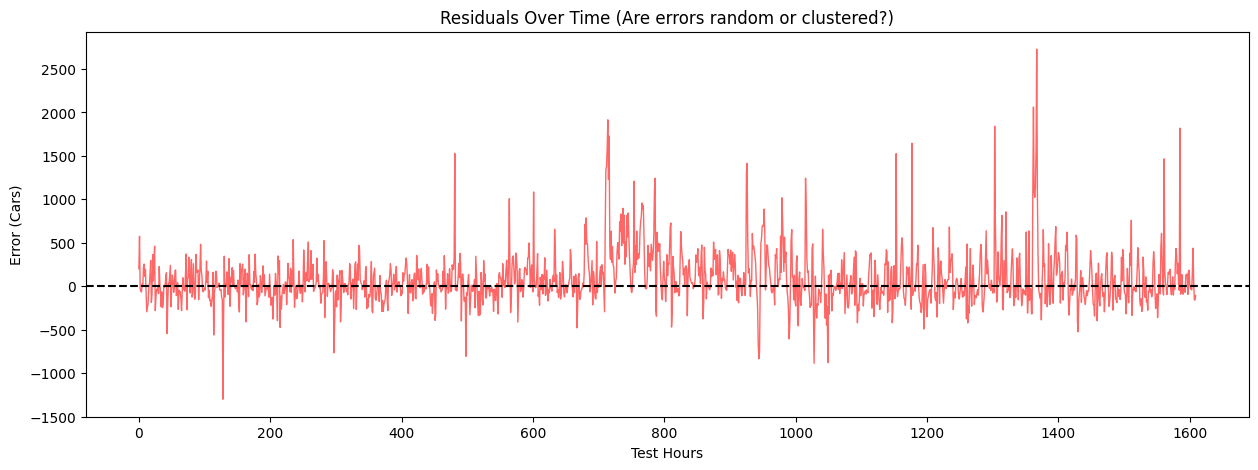

/tmp/ipython-input-2569068304.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hour', y='Error', data=results_df, palette="coolwarm")


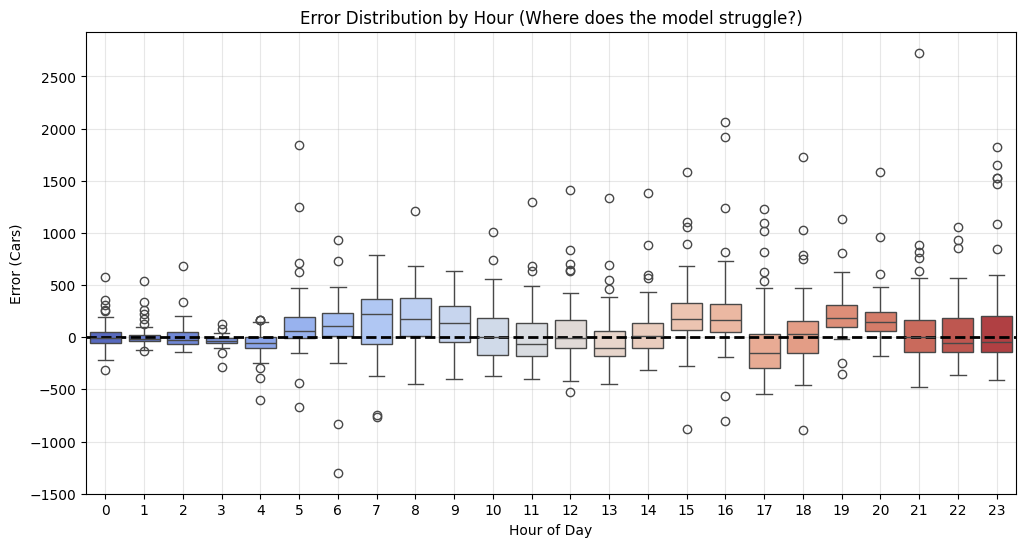

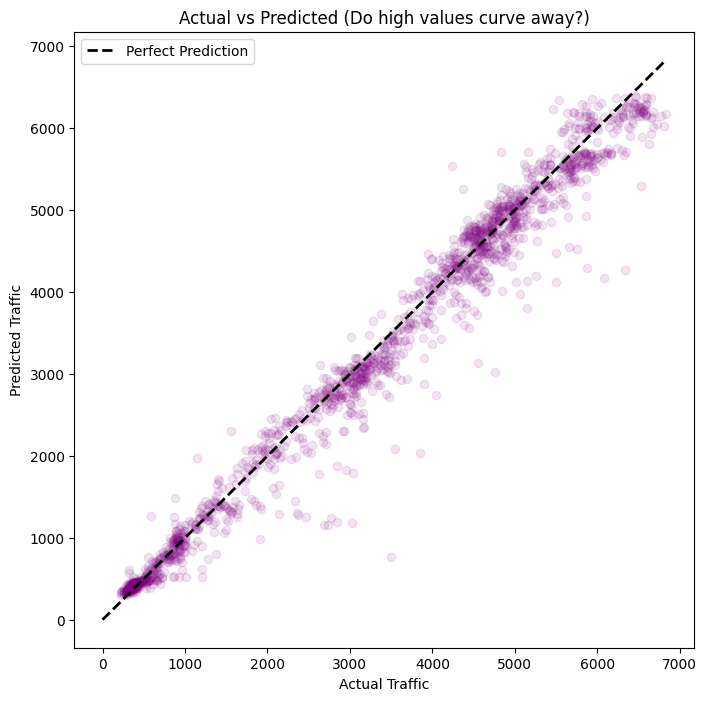

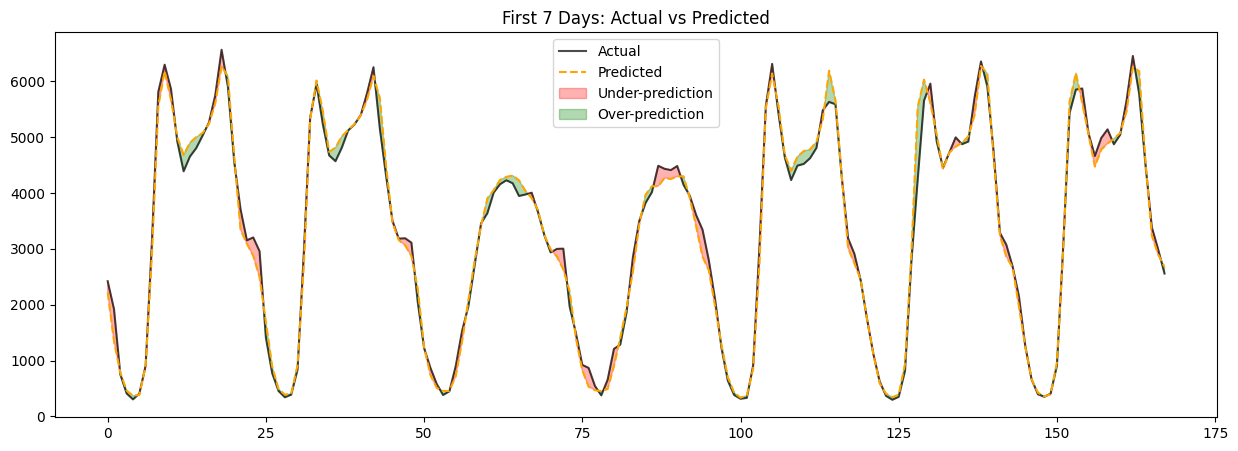

In [53]:
  # 6

def plot_result(test_df, predictions_real, y_test_real):

    # 1. Recover the Hour from Sin/Cos
    # We use arctan2 to get the angle back, then convert to 0-23 range
    # Formula: angle = 2 * pi * hour / 24  -->  hour = angle * 24 / (2 * pi)
    angles = np.arctan2(test_df['hour_sin'], test_df['hour_cos'])
    recovered_hours = angles * (24 / (2 * np.pi))

    # Adjust for negative angles (arctan2 returns -pi to +pi)
    recovered_hours = np.where(recovered_hours < 0, recovered_hours + 24, recovered_hours)
    recovered_hours = np.round(recovered_hours).astype(int)

    # 2. Build the Results DataFrame
    # Note: predictions_real and y_test_real might need flattening (.flatten())
    results_df = pd.DataFrame({
        'Actual': y_test_real.flatten(),
        'Predicted': predictions_real.flatten(),
        'Error': y_test_real.flatten() - predictions_real.flatten(),
        'Hour': recovered_hours,
        # We can also recover weekend status if needed
        'IsWeekend': test_df['is_weekend'].values
    })


    # --- VISUALIZATION ---

    # 2. Plot 1: The Timeline of Errors (Spotting "Bursts")
    plt.figure(figsize=(15, 5))
    plt.plot(results_df['Error'], color='red', alpha=0.6, linewidth=1)
    plt.axhline(0, color='black', linestyle='--')
    plt.title("Residuals Over Time (Are errors random or clustered?)")
    plt.ylabel("Error (Cars)")
    plt.xlabel("Test Hours")
    plt.show()

    # Plot 1: Error Distribution by Hour (The "Rush Hour" Test)
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Hour', y='Error', data=results_df, palette="coolwarm")
    plt.axhline(0, color='black', linestyle='--', linewidth=2)
    plt.title("Error Distribution by Hour (Where does the model struggle?)")
    plt.ylabel("Error (Cars)")
    plt.xlabel("Hour of Day")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot 2: Prediction Integrity (Bias Check)
    plt.figure(figsize=(8, 8))
    plt.scatter(results_df['Actual'], results_df['Predicted'], alpha=0.1, color='purple')
    # Draw the "Perfect Prediction" line
    max_val = max(results_df['Actual'].max(), results_df['Predicted'].max())
    plt.plot([0, max_val], [0, max_val], 'k--', lw=2, label='Perfect Prediction')
    plt.xlabel("Actual Traffic")
    plt.ylabel("Predicted Traffic")
    plt.title("Actual vs Predicted (Do high values curve away?)")
    plt.legend()
    plt.show()

    # Plot 3: Zoomed Timeline (First 168 hours = 1 Week)
    # This helps you see if the model misses the weekend pattern
    subset = results_df.iloc[:168]
    plt.figure(figsize=(15, 5))
    plt.plot(subset['Actual'].values, label='Actual', color='black', alpha=0.7)
    plt.plot(subset['Predicted'].values, label='Predicted', color='orange', linestyle='--')
    plt.fill_between(range(len(subset)), subset['Actual'], subset['Predicted'],
                    where=(subset['Actual'] > subset['Predicted']),
                    interpolate=True, color='red', alpha=0.3, label='Under-prediction')
    plt.fill_between(range(len(subset)), subset['Actual'], subset['Predicted'],
                    where=(subset['Actual'] < subset['Predicted']),
                    interpolate=True, color='green', alpha=0.3, label='Over-prediction')
    plt.title("First 7 Days: Actual vs Predicted")
    plt.legend()
    plt.show()

plot_result(test_df, predictions_real_lstm, y_test_real_lstm)

#### Error Diagnostics Summary

#####
## Residual Analysis: What the Errors Reveal

### 1. The “Negative Trenches” (Missed Insight)

**Observation:**  
Sharp downward spikes in the residuals (e.g., around x ≈ 120 and x ≈ 950), reaching **−1500**.

**Interpretation (Math):**  
Error = Actual − Predicted  
A −1500 error means the model predicted ~3,500 cars while the actual traffic was ~2,000.

**Scenario:**  
The model signaled a major traffic jam, but the roads were unusually empty.

**Likely Cause:**  
Uncaptured calendar effects — most likely **holidays or bridge days** (e.g., the Friday after a public holiday) that were **not flagged by the `is_holiday` feature**.  
The model assumed a normal weekday pattern and overestimated demand.

---

### 2. The “Positive Explosions” (Confirming Morning Inertia)
**Observation:**  
Frequent and extreme upward spikes (e.g., x ≈ 780, 800, 1000), reaching **+2800**.

**Scenario:**  
The model predicted normal traffic levels, but reality was severe congestion.

**Confirmation:**  
This directly aligns with the **morning-hour (6–7 AM) boxplot outliers**, reinforcing the diagnosis of **morning rush inertia**—the model reacts too slowly to rapid demand surges.


## Boxplot

### 1. Morning Rush Inertia (Hours 5–7)
**Observation:**  
The boxplots and medians are shifted **above the zero line**.

**Interpretation:**  
Errors are consistently positive (*Actual − Predicted > 0*).

**Meaning:**  
The model **systematically under-predicts morning traffic**.  
When traffic surges sharply (≈500 → 4,000 cars between 5–7 AM), the LSTM reacts too slowly—capturing the upward trend but not its steepness.  
This suggests a **conservative bias**, likely averaging peak days with lower-traffic days.

---

### 2. Night Watch Performance (Hours 0–4)
**Observation:**  
Boxes are small and centered around zero.

**Interpretation & Meaning:**  
The model performs **near-perfectly at night**, where traffic is low and stable—an easy regime for the LSTM.

---

### 3. Afternoon Chaos (Hours 14–17)
**Observation:**  
Under-prediction reappears, but with **lower variance** than the morning.

**Meaning:**  
The model struggles again during increased activity, though less severely.  
The **morning spike remains the hardest regime** for the model to learn.

---

## Scatter Plot Analysis

### Good News: No “Banana Curve”
**Observation:**  
The scatter remains **largely linear up to ~6,500 cars**.

**Interpretation:**  
The LSTM is **not saturating** and can represent high traffic volumes.  
This confirms the **model capacity and architecture are sufficient** to learn large values.

---

### Bad News: The Under-Prediction Shadow
**Observation:**  
The point cloud is **denser below the dashed diagonal** than above it.

**Interpretation:**  
The model **rarely over-predicts** but **frequently under-predicts**.

**Meaning:**  
There is a **systematic conservative bias**: the model prefers safe, lower estimates and fails to fully capture peak magnitudes, especially during surge periods.



### 1D-CNN

1. Using the 3D input that created before

3. Deep Learning Model

4. Train Model

5. Prediction

6. Evaluation

In [54]:
n_timesteps = X_train.shape[1] # 24
n_features = X_train.shape[2]  # e.g., 15

model_1dcnn = Sequential([
   # --- LAYER 1: The "Lag 1" Specialist ---
    # Kernel=2: Strictly looks at [t-1, t].
    # This mathematically forces it to learn the "Previous Hour Effect".
    # Padding='causal': Ensures we don't cheat by seeing the future.
    Conv1D(filters=64, kernel_size=2, dilation_rate=1, activation='relu', padding='causal', input_shape=(n_timesteps, n_features)),

    # SpatialDropout drops entire feature maps, forcing the model to be robust
    SpatialDropout1D(0.1),

    # --- LAYER 2: The "Trend" Watcher ---
    # Kernel=2, Dilation=2: Looks at [t-2, t].
    # Connects the immediate past to slightly older past.
    Conv1D(filters=64, kernel_size=2, dilation_rate=2, activation='relu', padding='causal'),
    SpatialDropout1D(0.1),

    # --- LAYER 3: The "Cycle" Hunter (The Telescope) ---
    # Kernel=2, Dilation=12: Looks at [t-12, t] and effectively [t-24] via the stack.
    # This allows it to compare "Morning" vs "Evening" contexts.
    Conv1D(filters=64, kernel_size=2, dilation_rate=3, activation='relu', padding='causal'),
    SpatialDropout1D(0.1),


    # --- DECISION ---
    Flatten(), # coba global avg pooling

    Dense(32, activation='relu'),
    Dense(1)
])

# 2. Compile with MAE (as requested)
model_1dcnn.compile(optimizer='adam', loss='mae')
model_1dcnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 24, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 24, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 24, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 24, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        49,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,713 (264.50 KB)

 Trainable params: 67,713 (264.50 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# 3. Train
print("Starting CNN Training...")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_cnn = model_1dcnn.fit(
    X_train, y_train,
    epochs=100, # It often converges fast, likely < 50
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)

Starting CNN Training...


In [56]:
predictions_real_1dcnn, y_test_real_1dcnn = predict_with_model(model_1dcnn, X_test, target_scaler)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
=== MODEL EVALUATION REPORT ===
MAE  (Mean Absolute Error)     :  235.99 cars
RMSE (Root Mean Squared Error) :  378.30 cars
R²   (Explained Variance)      :  0.9620 
MASE (vs Naive Baseline)       :  0.4856 
MASE (vs Prophet Baseline)     :  0.8271 


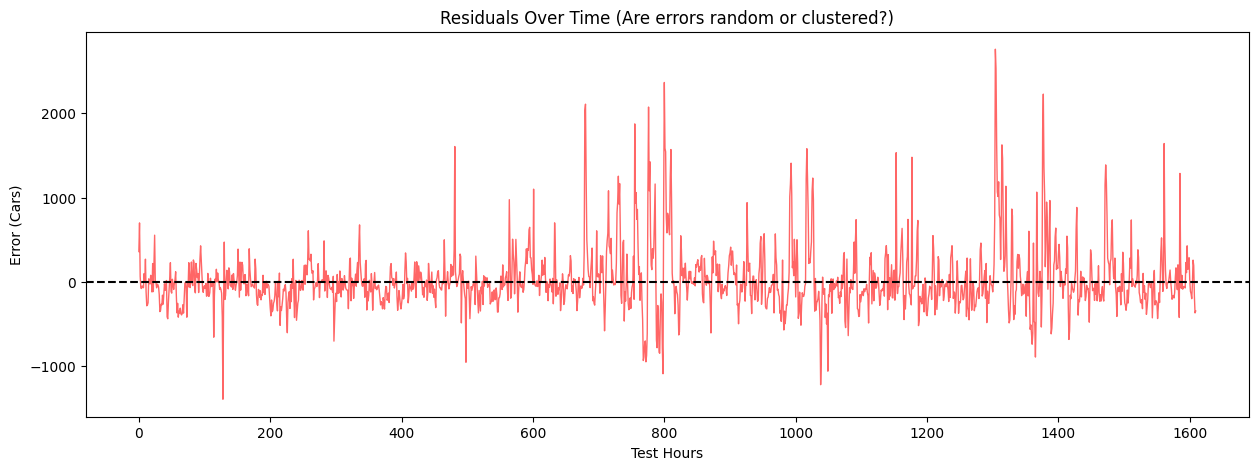

/tmp/ipython-input-2569068304.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hour', y='Error', data=results_df, palette="coolwarm")


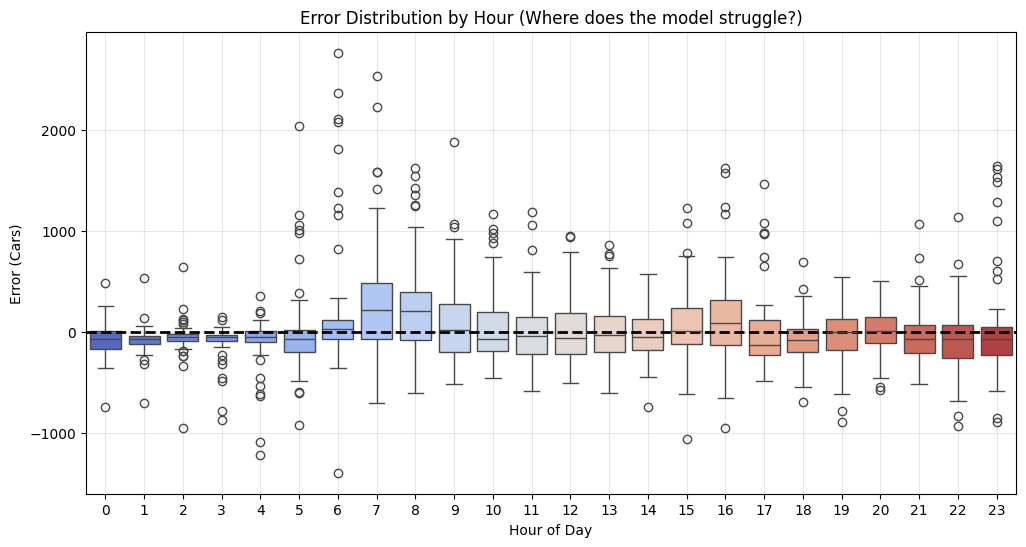

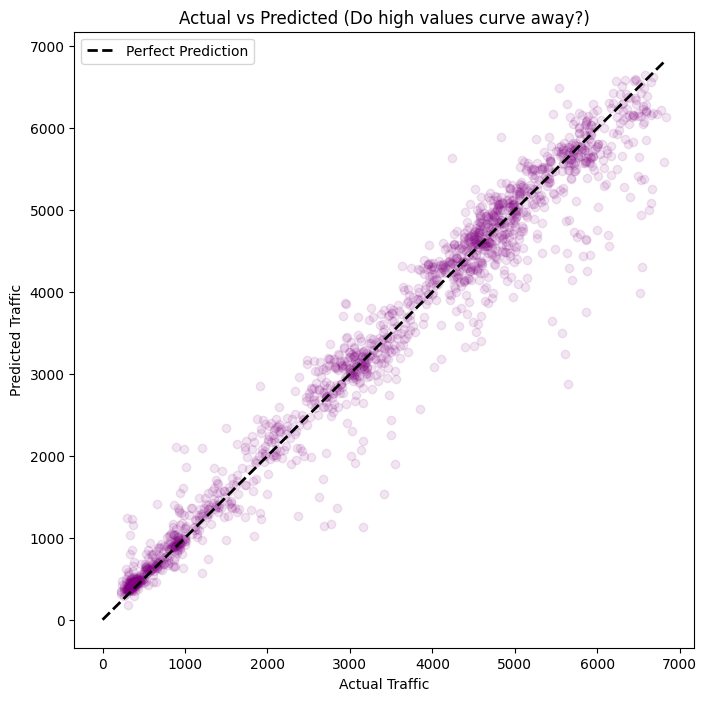

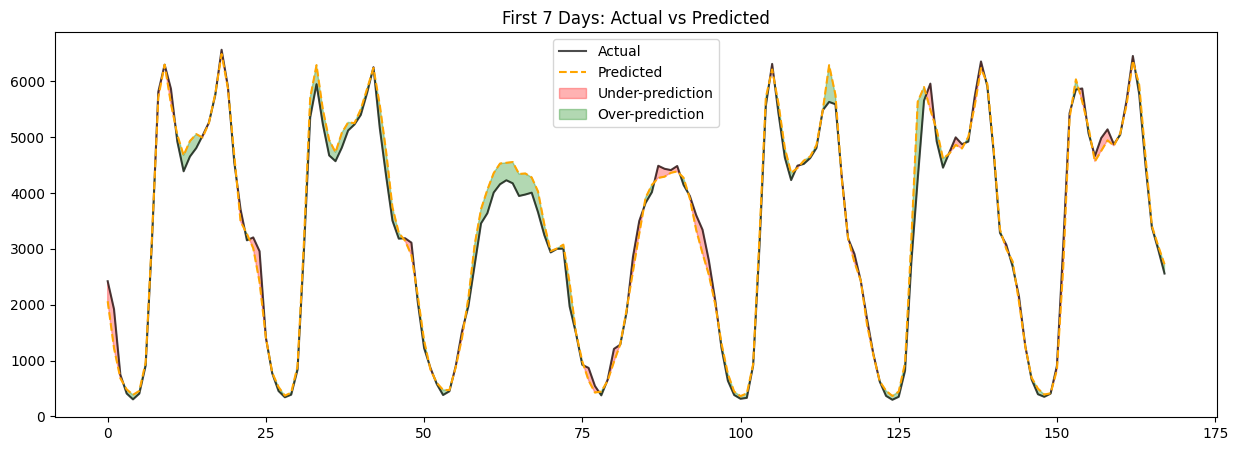

In [57]:
plot_result(test_df, predictions_real_1dcnn, y_test_real_1dcnn)

## Ensemble
1. XGBoost
2. LGBoost
3. CatBoost

In [58]:
df_ensemble = df_ready.copy()

target_col = 'traffic_volume'
X = df_ensemble.drop(columns=[target_col])
y = df_ensemble[target_col]

X_train_ensemble = X.iloc[:train_end]
y_train_ensemble = y.iloc[:train_end]
X_val_ensemble   = X.iloc[train_end:val_end]
y_val_ensemble   = y.iloc[train_end:val_end]
X_test_ensemble  = X.iloc[val_end:]
y_test_ensemble  = y.iloc[val_end:]


In [59]:
# Hypertunning
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'early_stopping_rounds': 50,
        'random_state': 42,
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }
    model = xgb.XGBRegressor(**param)
    model.fit(
        X_train_ensemble, y_train_ensemble,
        eval_set=[(X_val_ensemble, y_val_ensemble)],
        verbose=False
    )
    preds = model.predict(X_val_ensemble)
    rmse = np.sqrt(mean_squared_error(y_val_ensemble, preds))
    return rmse

def objective_lgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'lambda_l1': trial.suggest_float('lambda_l1', 0, 10),
        'lambda_l2': trial.suggest_float('lambda_l2', 0, 10),
        'n_jobs': -1,
        'random_state': 42,
        'verbose': -1,
        'objective': 'regression',
        'metric': 'rmse'
    }
    model = lgb.LGBMRegressor(**param)
    model.fit(
        X_train_ensemble, y_train_ensemble,
        eval_set=[(X_val_ensemble, y_val_ensemble)],
        eval_metric='rmse',
        callbacks=[log_evaluation(0)]
    )
    preds = model.predict(X_val_ensemble)
    rmse = np.sqrt(mean_squared_error(y_val_ensemble, preds))
    return rmse

def objective_cat(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'loss_function': 'RMSE',
        'verbose': False,
        'random_state': 42,
    }
    model = CatBoostRegressor(**param)
    model.fit(
        X_train_ensemble, y_train_ensemble,
        eval_set=(X_val_ensemble, y_val_ensemble),
        early_stopping_rounds=50
    )

    preds = model.predict(X_val_ensemble)
    rmse = np.sqrt(mean_squared_error(y_val_ensemble, preds))
    return rmse


tunning = False

if tunning :
  print("--- 5 Trials (increase if need more optimization) ---")
  n_trials = 10

  print("--- Tuning XGBoost (RMSE) ---")
  study_xgb = optuna.create_study(direction='minimize')
  study_xgb.optimize(objective_xgb, n_trials)

  print("\n--- Tuning LightGBM (RMSE) ---")
  study_lgb = optuna.create_study(direction='minimize')
  study_lgb.optimize(objective_lgb, n_trials)

  print("\n--- Tuning CatBoost (RMSE) ---")
  study_cat = optuna.create_study(direction='minimize')
  study_cat.optimize(objective_cat, n_trials)

  print("\n--- TUNING COMPLETE ---")
  print(f"Best XGB Params: {study_xgb.best_params}")
  print(f"Best LGB Params: {study_lgb.best_params}")
  print(f"Best CAT Params: {study_cat.best_params}")
else :
  print("Using the latest tunned hyperparam")

Using the latest tunned hyperparam


In [60]:
# --- TUNING COMPLETE USING DL INPUT---
tunned_best_XGB = {'n_estimators': 1074, 'max_depth': 7, 'learning_rate': 0.0783890087615332, 'subsample': 0.6558843699488984, 'colsample_bytree': 0.9870651814612088, 'min_child_weight': 2, 'gamma': 0.28227151504069503, 'reg_alpha': 1.0526869705293163, 'reg_lambda': 0.8268371800982488}
tunned_best_LGB = {'n_estimators': 786, 'num_leaves': 99, 'learning_rate': 0.020201679107383602, 'feature_fraction': 0.8421191500216104, 'bagging_fraction': 0.7744187827948728, 'bagging_freq': 2, 'lambda_l1': 0.18947304622224714, 'lambda_l2': 0.722944128612466}
tunnet_best_CB = {'iterations': 1820, 'depth': 6, 'learning_rate': 0.03622942540865213, 'l2_leaf_reg': 9.561704750262008, 'border_count': 96}

# --- TUNING COMPLETE USING ENSEMBLE INPUT---
tunned_best_XGB = {'n_estimators': 659, 'max_depth': 10, 'learning_rate': 0.020252313802669338, 'subsample': 0.7476391566476699, 'colsample_bytree': 0.8216437646615009, 'min_child_weight': 6, 'gamma': 0.33413612533162873, 'reg_alpha': 0.7013592689716686, 'reg_lambda': 3.3868083944291794}
tunned_best_LGB = {'n_estimators': 944, 'num_leaves': 39, 'learning_rate': 0.011757903299920713, 'feature_fraction': 0.8429456171464971, 'bagging_fraction': 0.884167058620932, 'bagging_freq': 1, 'lambda_l1': 7.543386830209627, 'lambda_l2': 7.318252473952396}
tunned_best_CB = {'iterations': 1835, 'depth': 4, 'learning_rate': 0.042232433979711353, 'l2_leaf_reg': 5.548977096532343, 'border_count': 103}

# Train best model with the same static input
static_xgb = {'random_state': 42,'objective': 'reg:squarederror','eval_metric': 'rmse','early_stopping_rounds': 50}
static_lgb = {'n_jobs': -1,'random_state': 42,'verbose': -1,'objective': 'regression', 'metric': 'rmse'}
static_cat = {'loss_function': 'RMSE','verbose': False,'random_state': 42}

if tunning :
  best_xgb = xgb.XGBRegressor(**static_xgb, **study_xgb.best_params)
  best_xgb.fit(X_train_ensemble, y_train_ensemble,eval_set=[(X_val_ensemble, y_val_ensemble)],verbose=False)

  best_lgb = lgb.LGBMRegressor(**static_lgb, **study_lgb.best_params)
  best_lgb.fit(X_train_ensemble, y_train_ensemble,eval_set=[(X_val_ensemble, y_val_ensemble)],callbacks=[early_stopping(50), log_evaluation(0)])

  best_cb = CatBoostRegressor(**static_cat, **study_cat.best_params)
  best_cb.fit(X_train_ensemble, y_train_ensemble,eval_set=(X_val_ensemble, y_val_ensemble),early_stopping_rounds=50)
else : # use the tune before
  best_xgb = xgb.XGBRegressor(**static_xgb, **tunned_best_XGB)
  best_xgb.fit(X_train_ensemble, y_train_ensemble,eval_set=[(X_val_ensemble, y_val_ensemble)],verbose=False)

  best_lgb = lgb.LGBMRegressor(**static_lgb, **tunned_best_LGB)
  best_lgb.fit(X_train_ensemble, y_train_ensemble,eval_set=[(X_val_ensemble, y_val_ensemble)],callbacks=[early_stopping(50), log_evaluation(0)])

  best_cb = CatBoostRegressor(**static_cat, **tunnet_best_CB)
  best_cb.fit(X_train_ensemble, y_train_ensemble,eval_set=(X_val_ensemble, y_val_ensemble),early_stopping_rounds=50)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[943]	valid_0's rmse: 212.192


In [61]:
# Ensambling and defining weight using grid search

pred_val_xgb = best_xgb.predict(X_val_ensemble)
pred_val_lgb = best_lgb.predict(X_val_ensemble)
pred_val_cat = best_cb.predict(X_val_ensemble)

best_rmse = float('inf')
best_weights = [0, 0, 0]

for w_xgb in range(101):
    for w_lgb in range(101):
        for w_cat in range(101):
            if w_xgb + w_lgb + w_cat != 100:
                continue
            wt = [w_xgb/100, w_lgb/100, w_cat/100]
            mix_pred = (wt[0] * pred_val_xgb) + (wt[1] * pred_val_lgb) + (wt[2] * pred_val_cat)
            score = np.sqrt(mean_squared_error(y_val_ensemble, mix_pred))
            if score < best_rmse:
                best_rmse = score
                best_weights = wt

print(f"Best Validation RMSE : {best_rmse:.5f}")
print(f"Best Weights -> \nXGB: {best_weights[0]}\nLGB: {best_weights[1]}\nCAT: {best_weights[2]}")

Best Validation RMSE : 204.81876
Best Weights -> 
XGB: 0.5
LGB: 0.01
CAT: 0.49


In [62]:
# Prediction

pred_test_xgb = best_xgb.predict(X_test_ensemble)
pred_test_lgb = best_lgb.predict(X_test_ensemble)
pred_test_cat = best_cb.predict(X_test_ensemble)

# Calculate Weighted Average (Ensemble)
ensemble_pred_test = (
    (best_weights[0] * pred_test_xgb) +
    (best_weights[1] * pred_test_lgb) +
    (best_weights[2] * pred_test_cat)
)

# --- 2. Evaluation Function (Updated for RAW Data) ---
def evaluate_ensemble_raw(y_true, y_pred, mae_naive=None, mae_prophet=None):
    # Ensure inputs are flat numpy arrays for safety
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    # Metrics Calculation (No Inverse Transform needed!)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print("=== FINAL ENSEMBLE EVALUATION REPORT (Tree Pipeline) ===")
    print(f"MAE               : {mae:.2f} cars")
    print(f"RMSE              : {rmse:.2f} cars")
    print(f"R²                : {r2:.4f}")

    if mae_naive:
        mase = mae / (mae_naive + 1e-10)
        print(f"MASE (vs Naive)   : {mase:.4f}")

    if mae_prophet:
        ratio_prophet = mae / (mae_prophet + 1e-10)
        print(f"MASE (vs Prophet) : {ratio_prophet:.4f}")

    return y_pred, y_true

# --- 3. Execute Evaluation ---
pred_real_ensemble, y_real_ensemble = evaluate_ensemble_raw(
    y_true=y_test_ensemble,
    y_pred=ensemble_pred_test,
    mae_naive=mae_naive,
    mae_prophet=mae_prophet
)

=== FINAL ENSEMBLE EVALUATION REPORT (Tree Pipeline) ===
MAE               : 133.85 cars
RMSE              : 207.66 cars
R²                : 0.9886
MASE (vs Naive)   : 0.2754
MASE (vs Prophet) : 0.4691


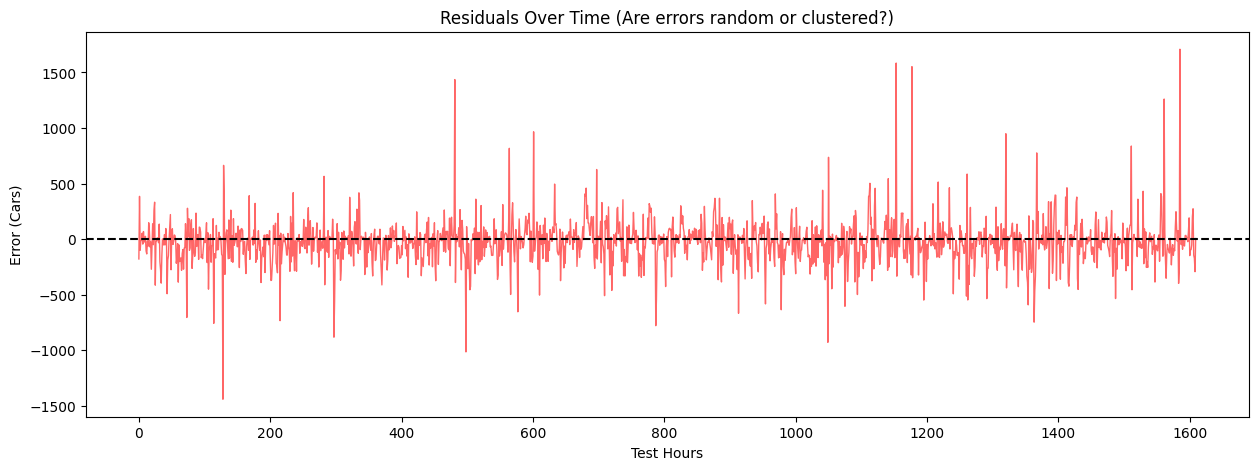

/tmp/ipython-input-2569068304.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hour', y='Error', data=results_df, palette="coolwarm")


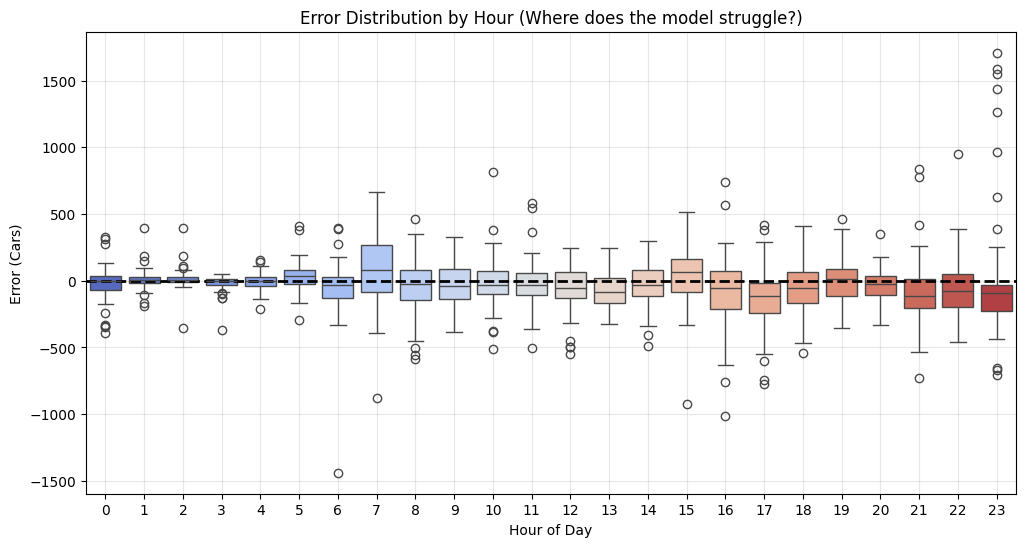

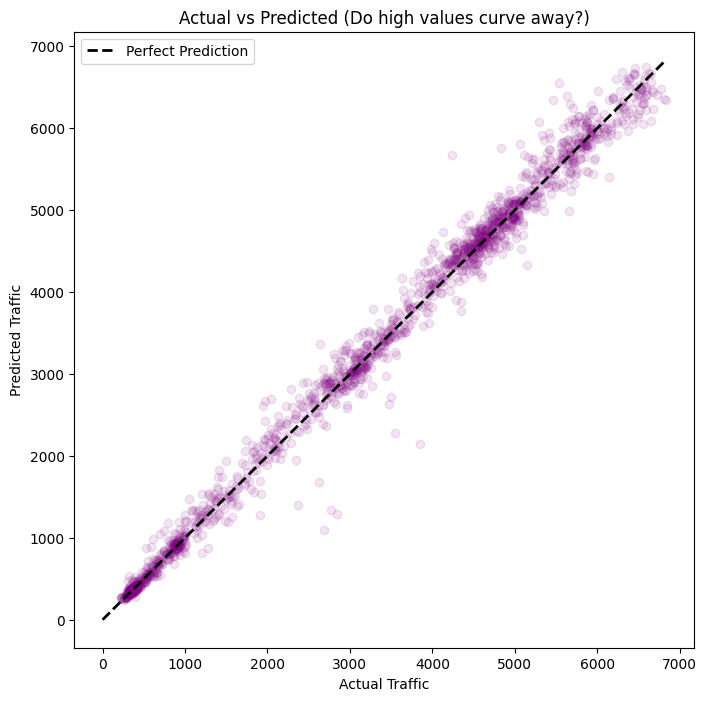

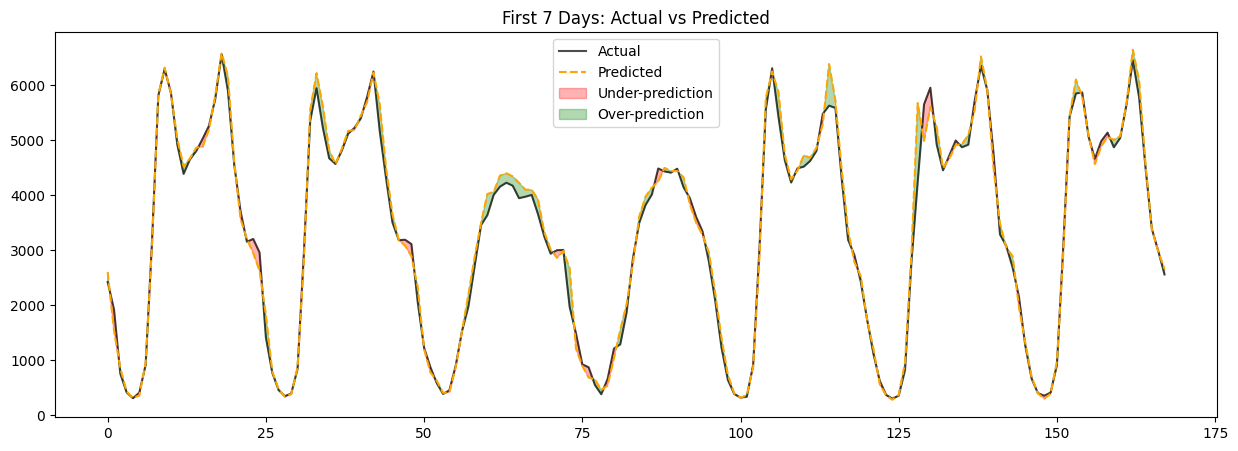

In [63]:
plot_result(test_df,pred_real_ensemble,y_real_ensemble)

## Model Evaluation

In [64]:
def calculate_row(model_name, y_true, y_pred, mae_naive_ref, mae_prophet_ref):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mase = mae / (mae_naive_ref + 1e-10)
    ratio_prophet = mae / (mae_prophet_ref + 1e-10)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "MASE (vs Naive)": mase,
        "MASE (vs Prophet)": ratio_prophet
    }

mae_naive_ref = mean_absolute_error(y_test_actual_naive, y_naive_pred)
mae_prophet_ref = mean_absolute_error(actuals, predictions)

data = []

data.append(calculate_row(
    "Seasonal Naive",
    y_test_actual_naive,
    y_naive_pred,
    mae_naive_ref,
    mae_prophet_ref
))

data.append(calculate_row(
    "Prophet",
    actuals,
    predictions,
    mae_naive_ref,
    mae_prophet_ref
))

data.append(calculate_row(
    "LSTM",
    y_test_real_lstm,
    predictions_real_lstm,
    mae_naive_ref,
    mae_prophet_ref
))

data.append(calculate_row(
    "1D-CNN",
    y_test_real_1dcnn,
    predictions_real_1dcnn,
    mae_naive_ref,
    mae_prophet_ref
))

data.append(calculate_row(
    "Ensemble",
    y_real_ensemble,
    pred_real_ensemble,
    mae_naive_ref,
    mae_prophet_ref
))

df_comparison = pd.DataFrame(data)
df_comparison.set_index("Model", inplace=True)
df_comparison.sort_values(by="RMSE", inplace=True)


display(df_comparison)

,MAE,RMSE,R2 Score,MASE (vs Naive),MASE (vs Prophet)
Model,,,,,
Ensemble,133.845761,207.656733,0.988556,0.275396,0.469088
LSTM,202.466655,315.504018,0.973582,0.416588,0.709584
1D-CNN,235.991378,378.297380,0.962019,0.485568,0.827078
Prophet,285.331587,442.062570,0.948136,0.587089,1.000000
Seasonal Naive,486.011180,932.210509,0.769365,1.000000,1.703321
